**Environment setup**

In [1]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


**Necessary parameter setup**

In [3]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [4]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [8]:
utility_link = '/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/PlotUtil.py'
with open(utility_link) as f: exec(f.read())

**Rosenbrock Example**

In [9]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# MSE vs Warmups:
pf_MSE_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Rosen_MSE.pkl"
pf_MSE_df = pd.read_pickle(pf_MSE_path)
# MSE vs nested Rhat:
pf_R_Hat_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Rosen_R_Hat.pkl"
pf_R_Hat_df = pd.read_pickle(pf_R_Hat_path)

*Original Paper: line plot*

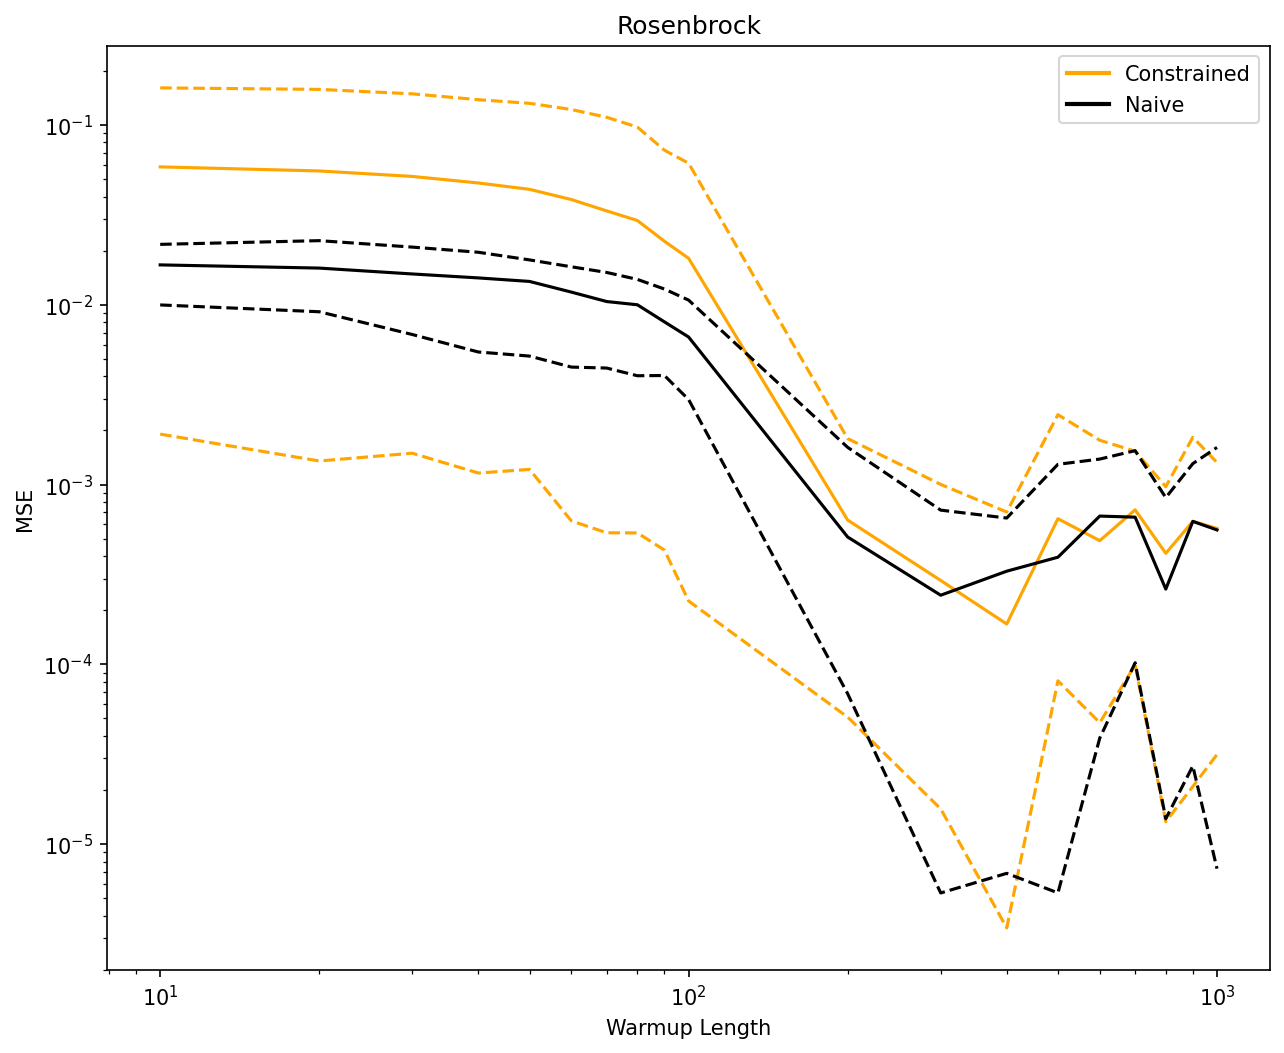

In [10]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Rosenbrock")

*Original Paper: Scatter plot*

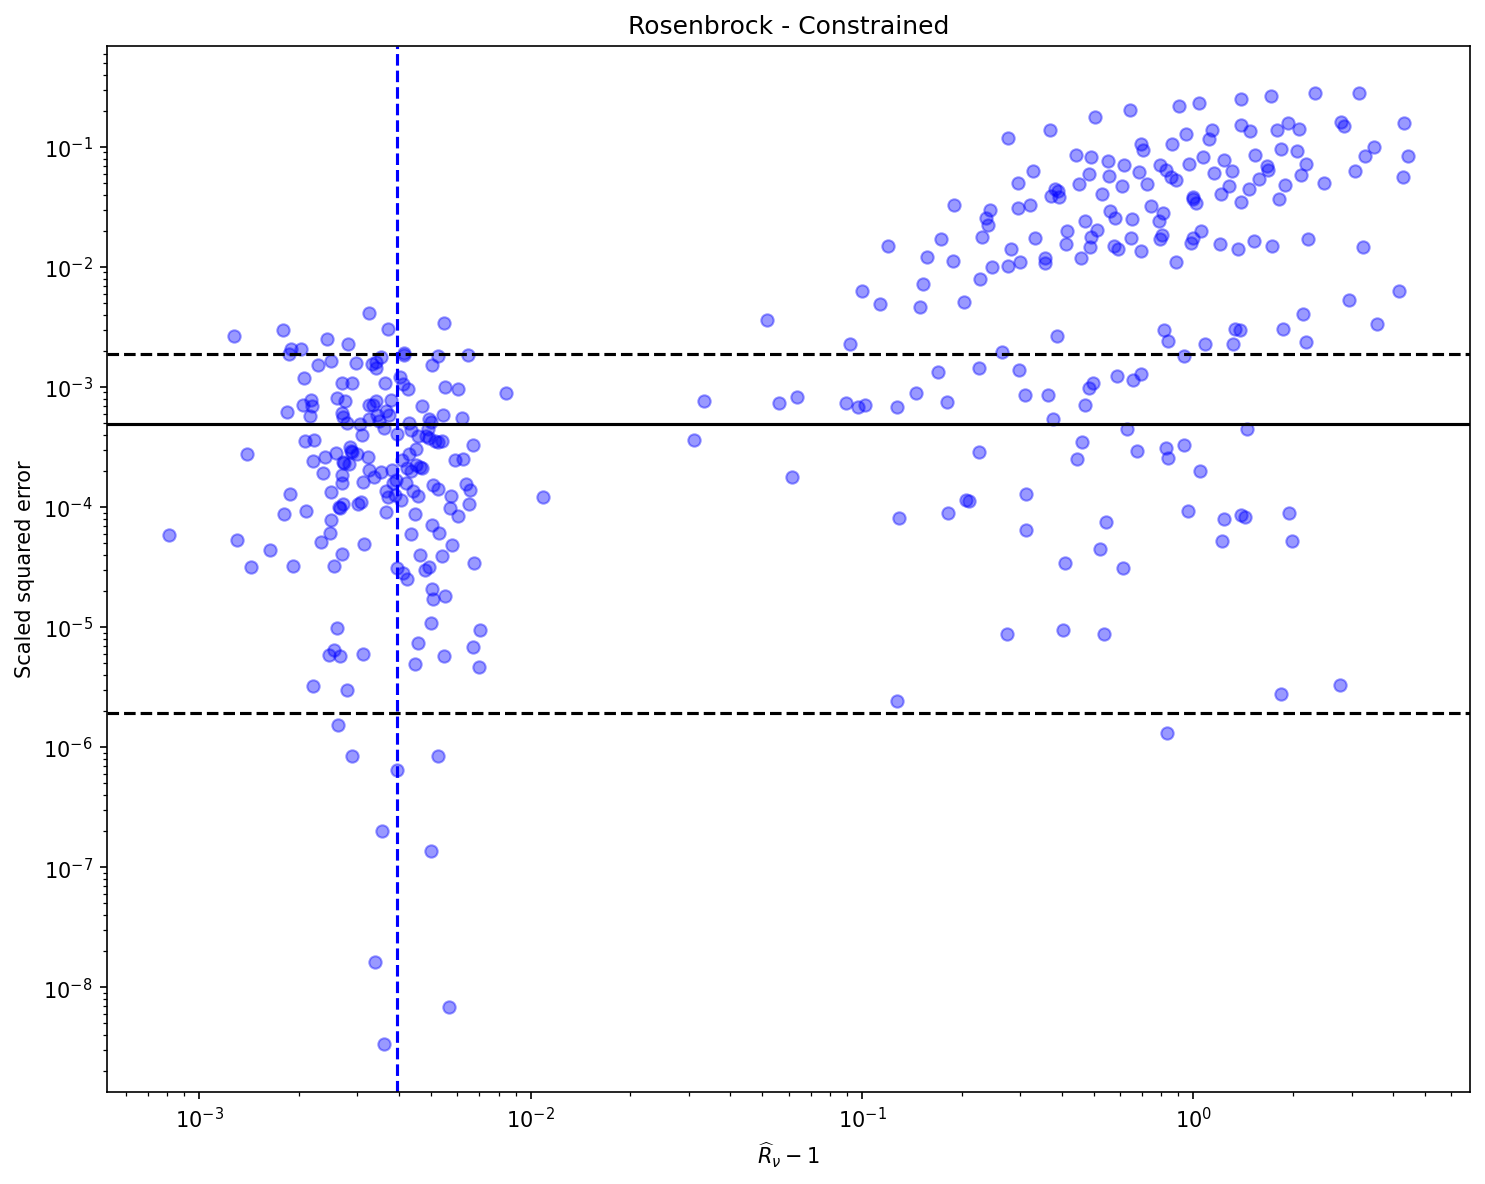

In [11]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Rosenbrock", False, bound, threshold,num_chains_short)

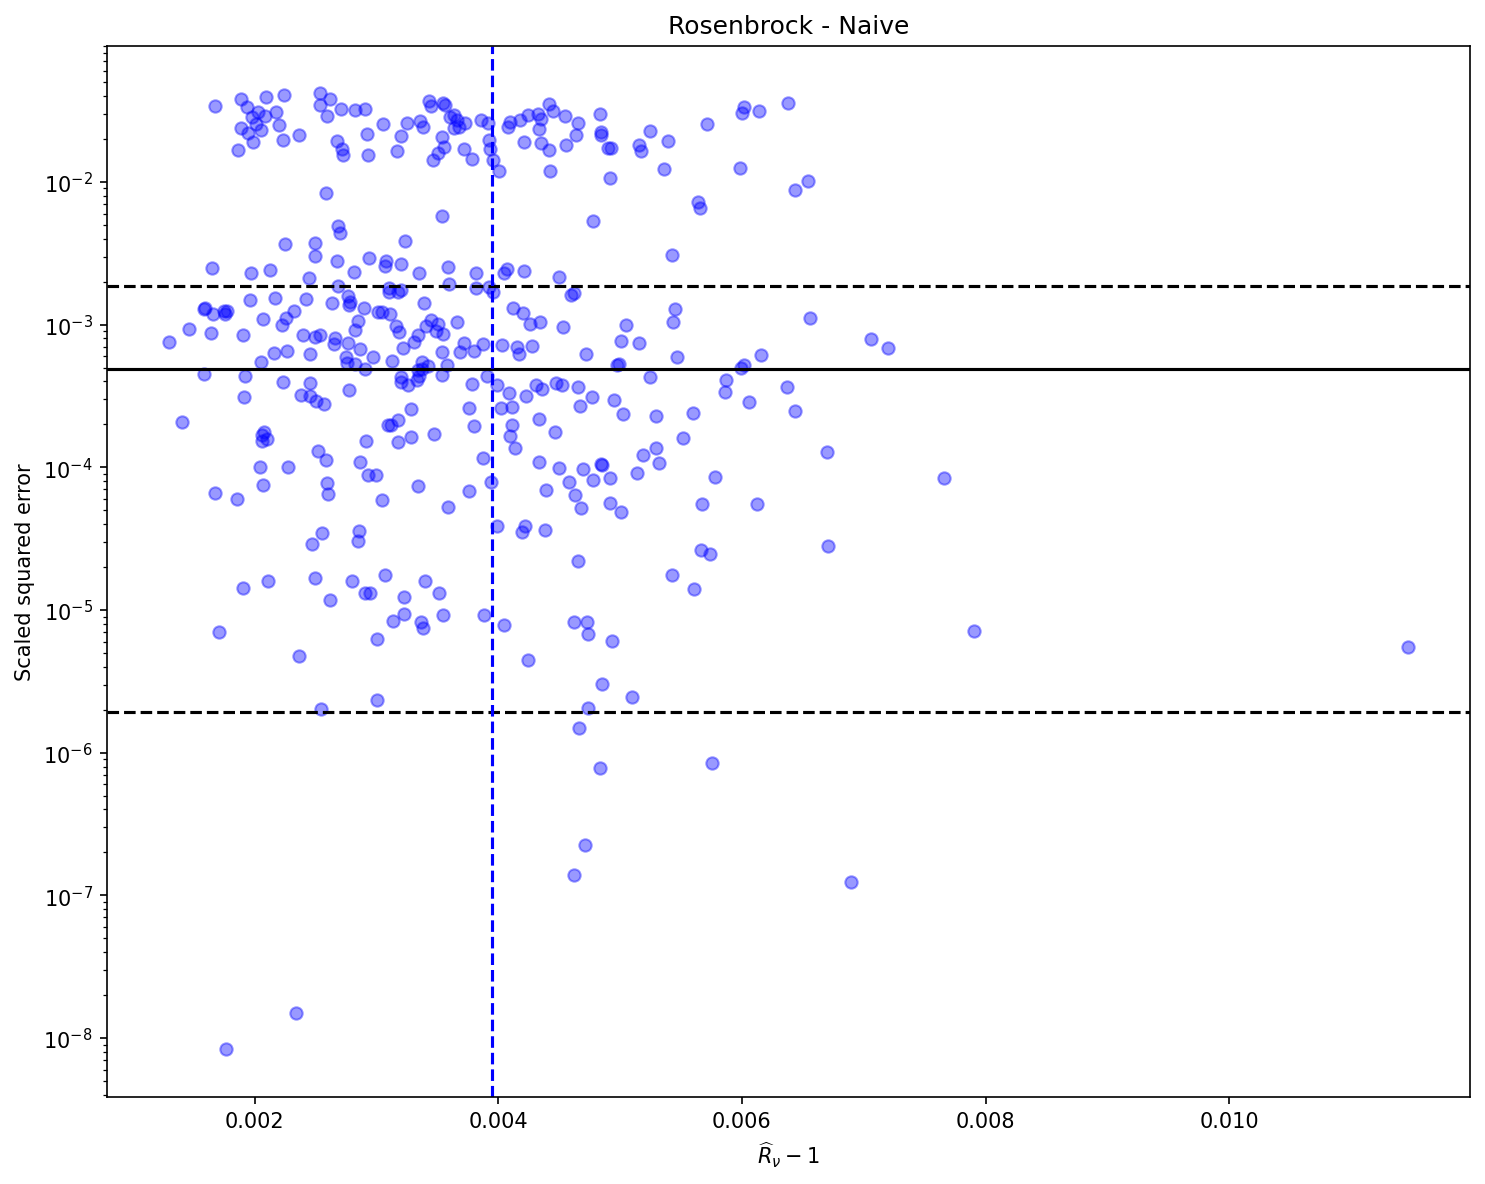

In [12]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Rosenbrock", True, bound, threshold,num_chains_short)

*Enhanced Plots: multiple line plots*

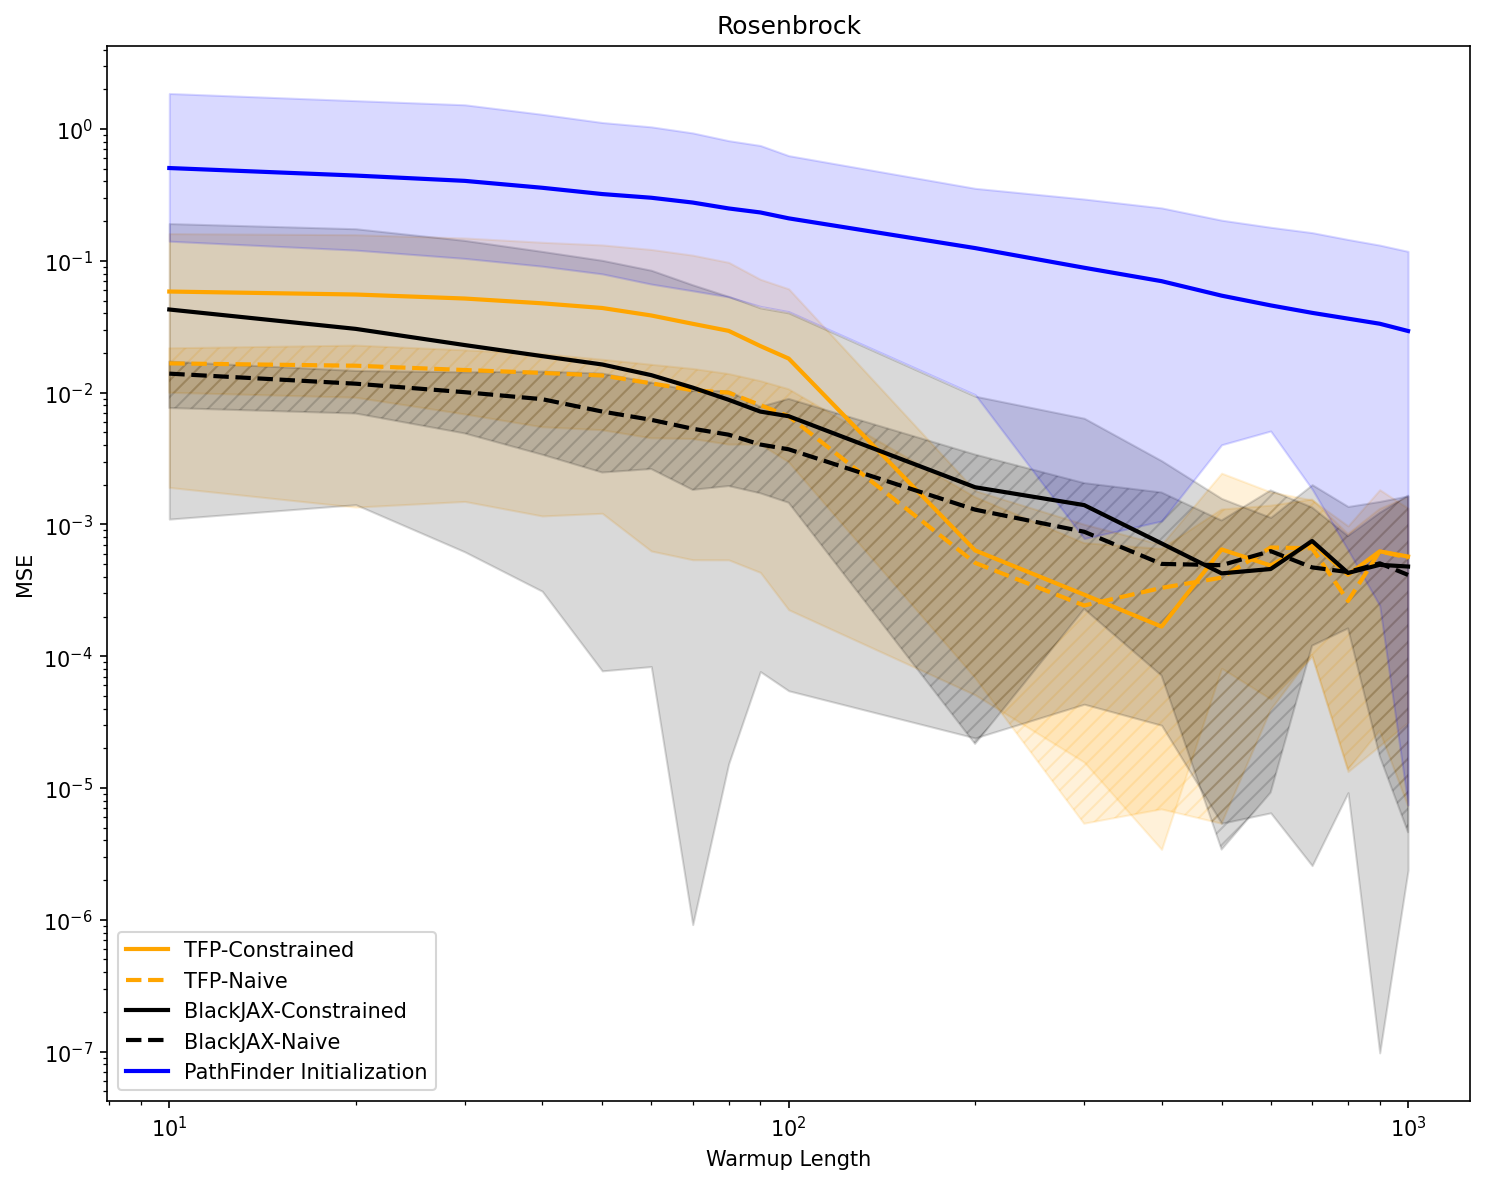

In [21]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_df, "Rosenbrock")

*Enhanced Plots: colored Scatter Plots*

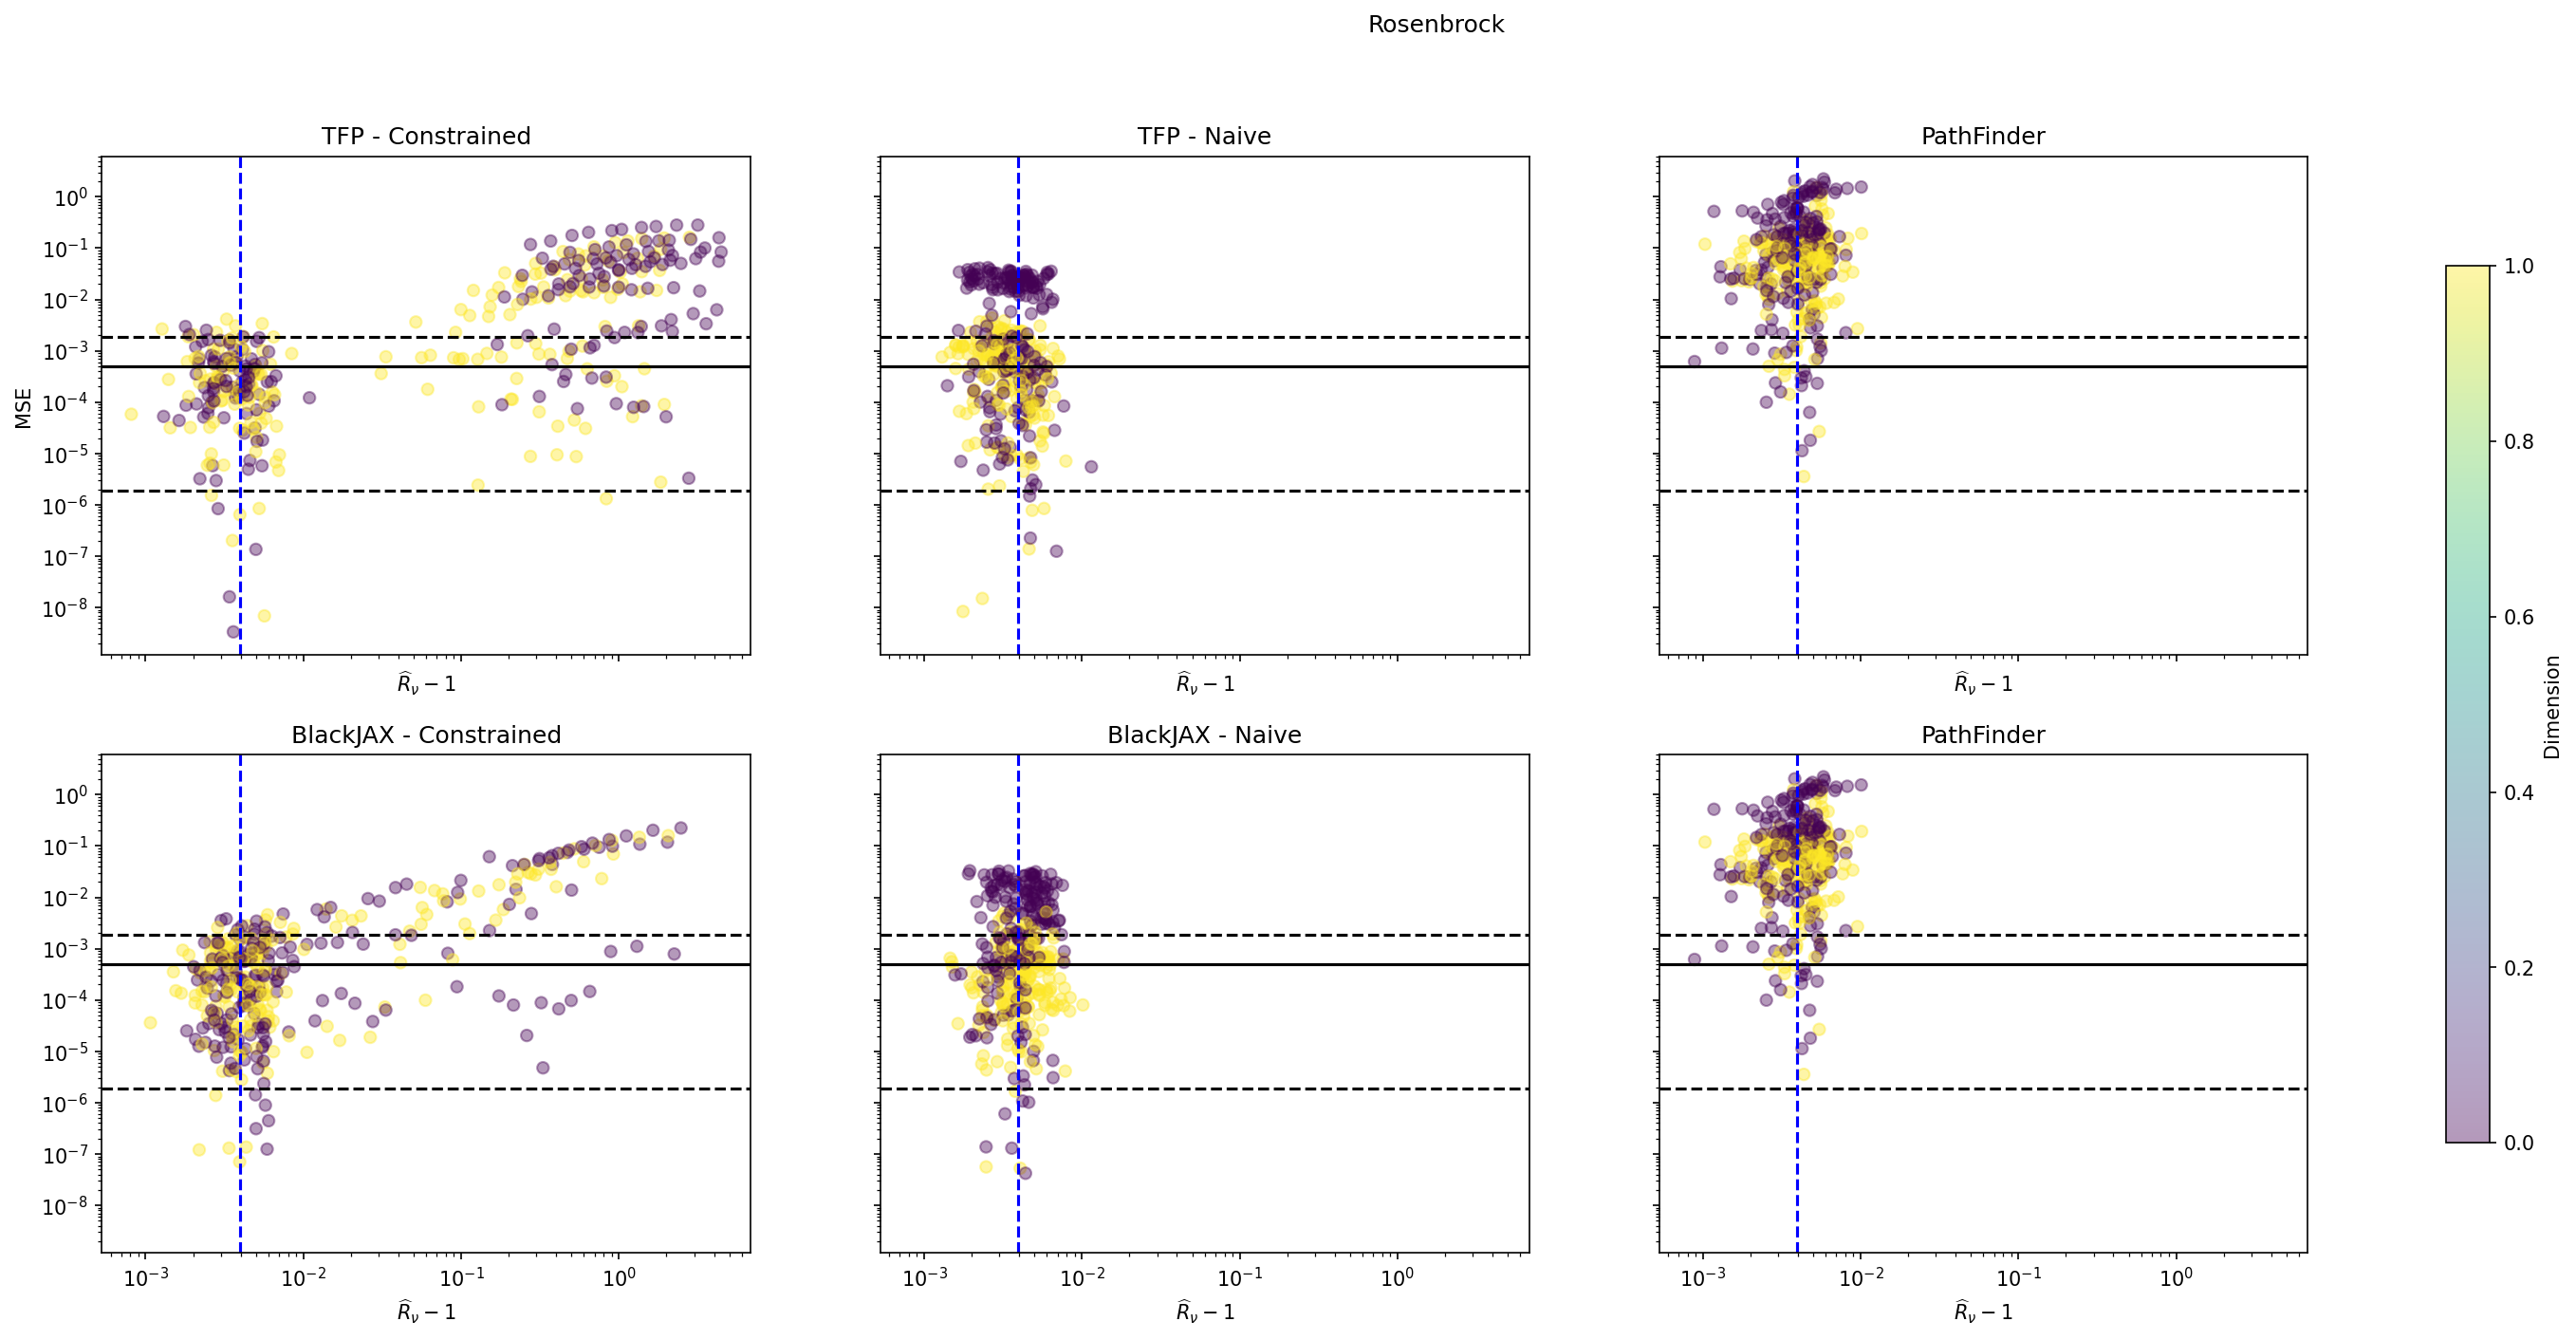

In [43]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Rosenbrock",bound, threshold,num_chains_short,"Dimension")

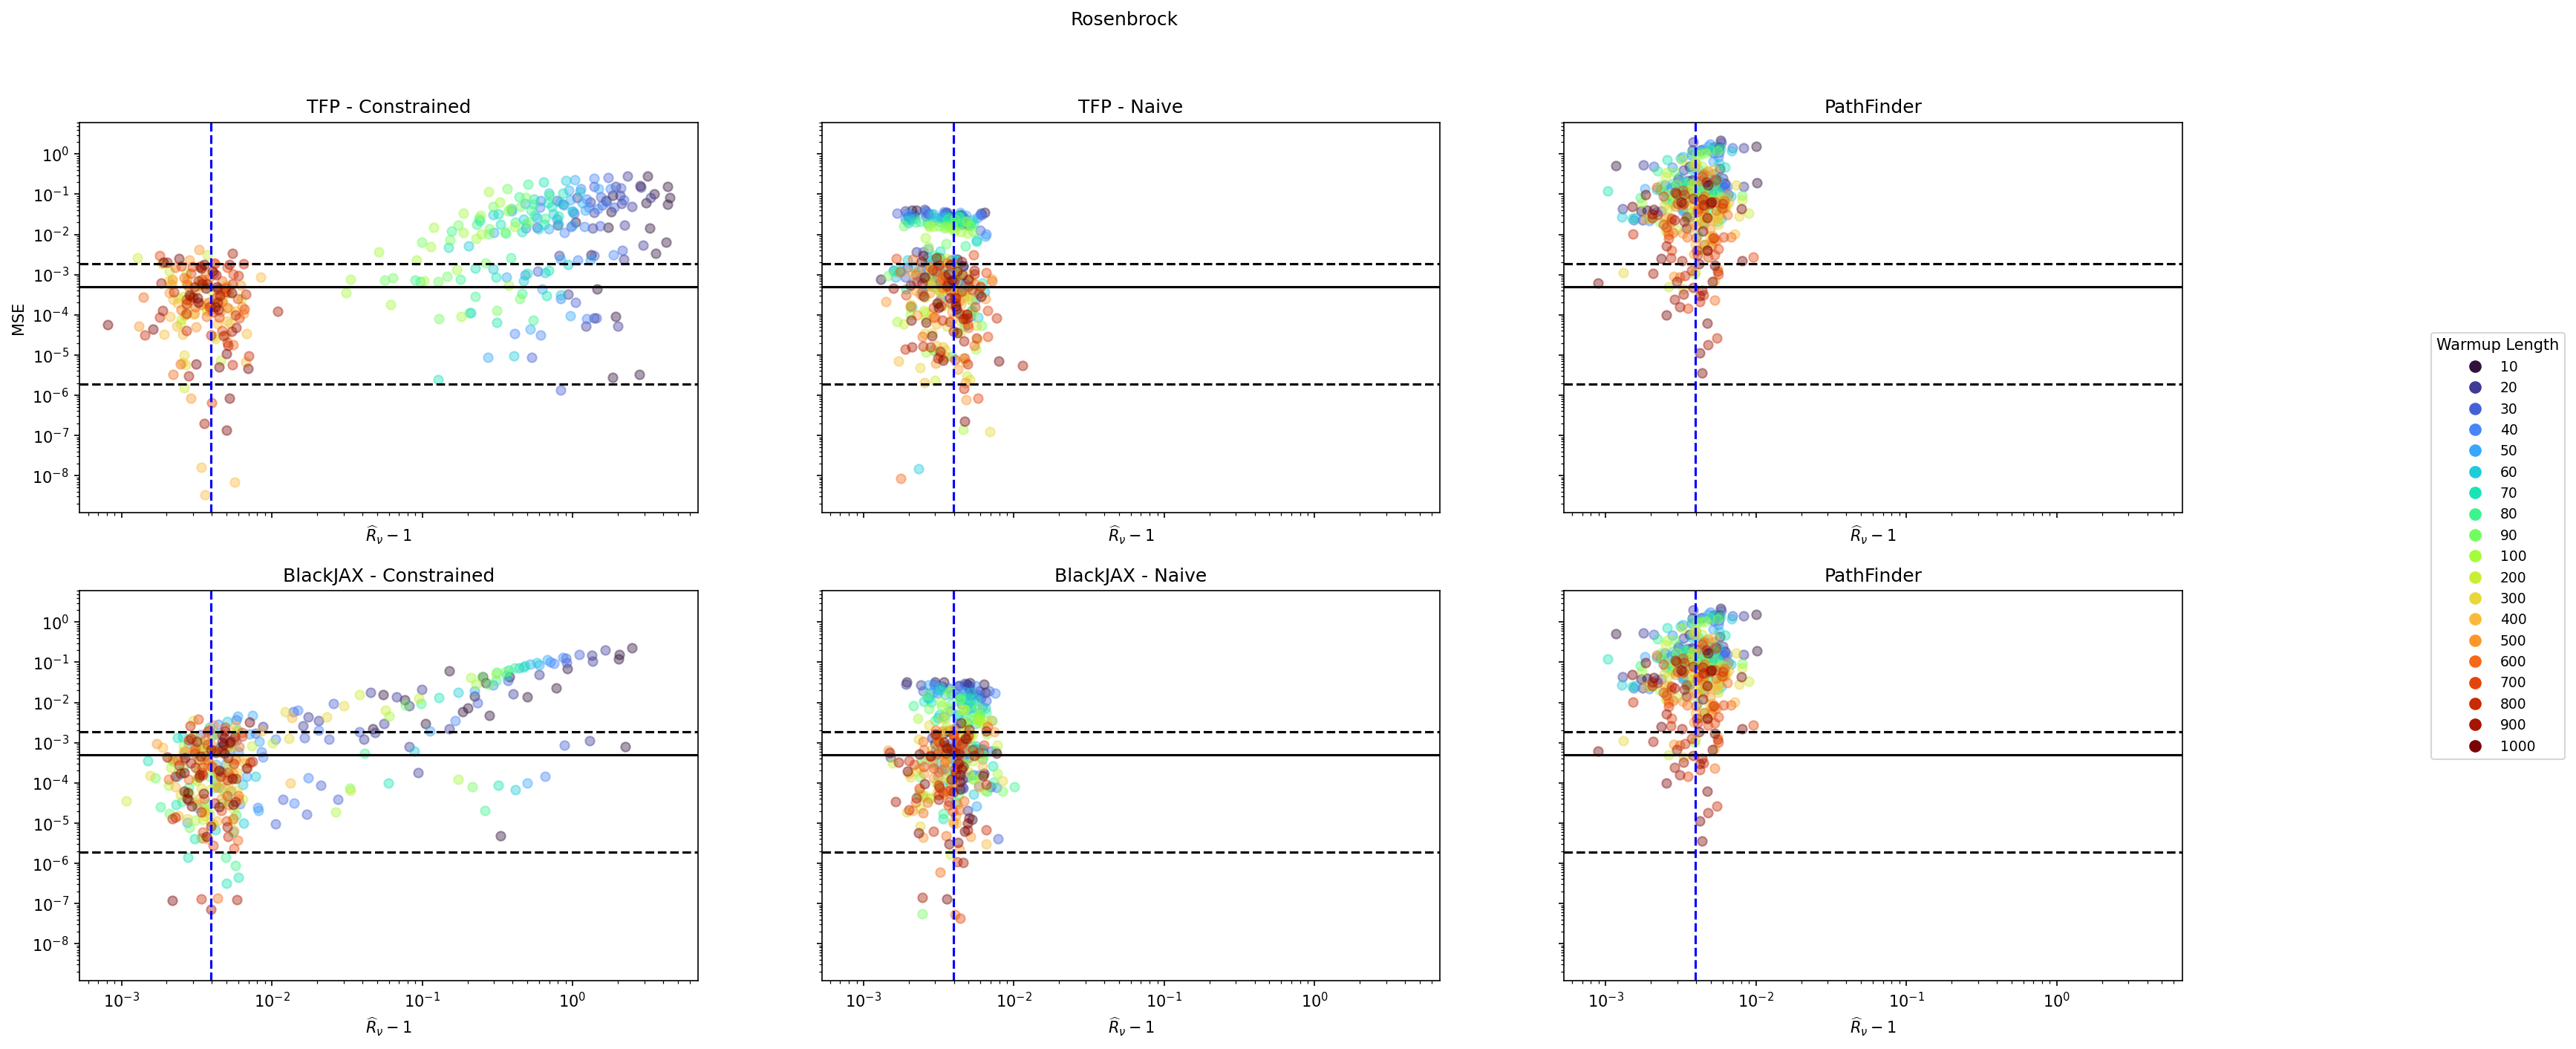

In [38]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Rosenbrock",bound, threshold,num_chains_short,"Warmup Length")

**Bimodal Example**

In [44]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# MSE vs Warmups:
pf_MSE_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Bim_MSE.pkl"
pf_MSE_df = pd.read_pickle(pf_MSE_path)
# MSE vs nested Rhat:
pf_R_Hat_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Bim_R_Hat.pkl"
pf_R_Hat_df = pd.read_pickle(pf_R_Hat_path)

*Original Paper: Line Plot*

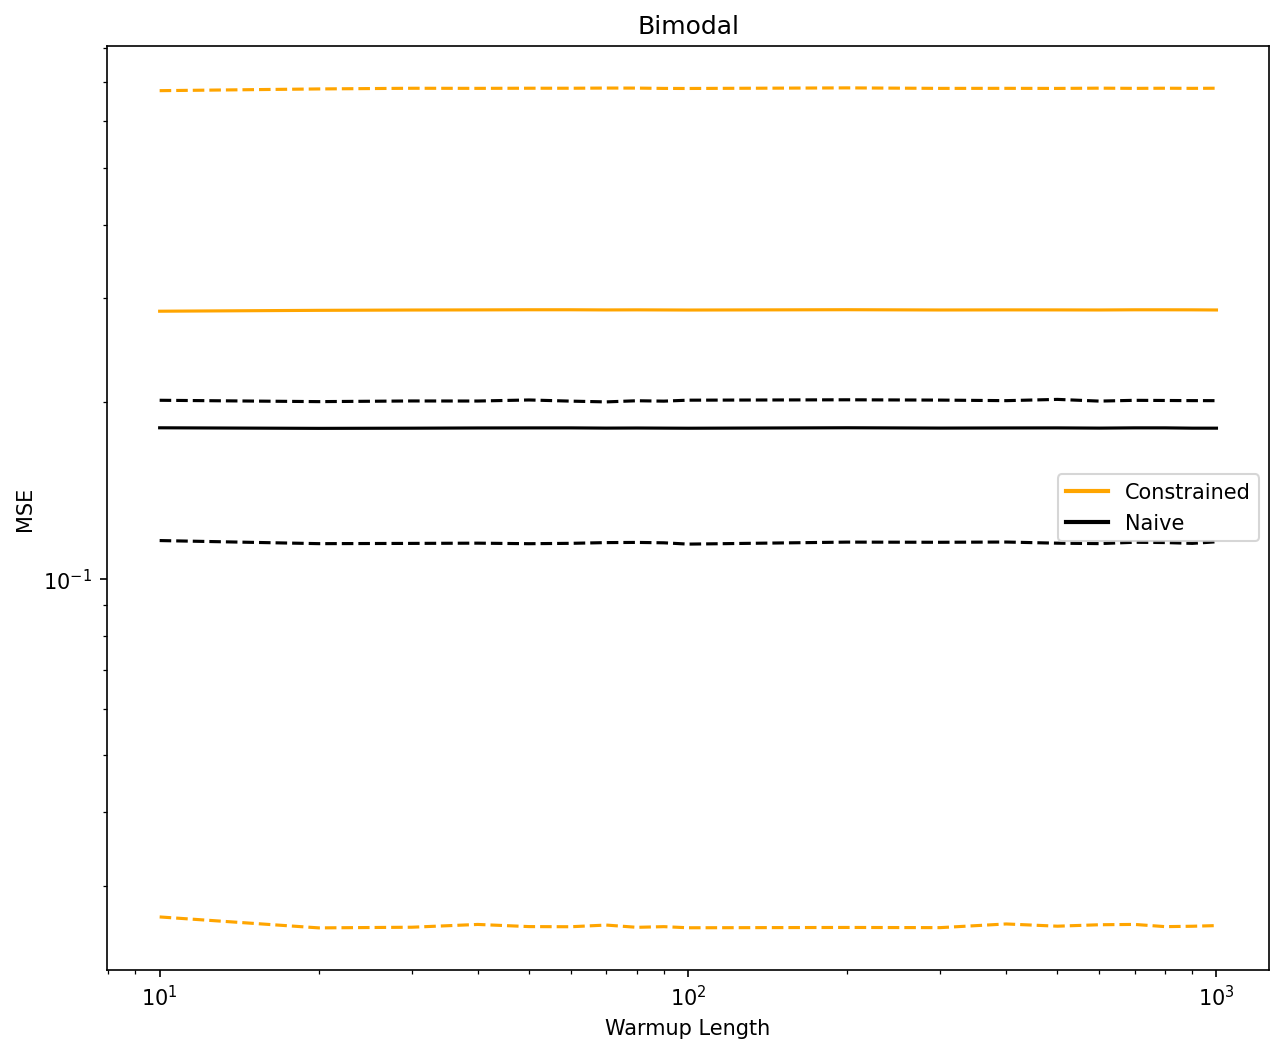

In [45]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Bimodal")

*Original Paper: Scatter plot*

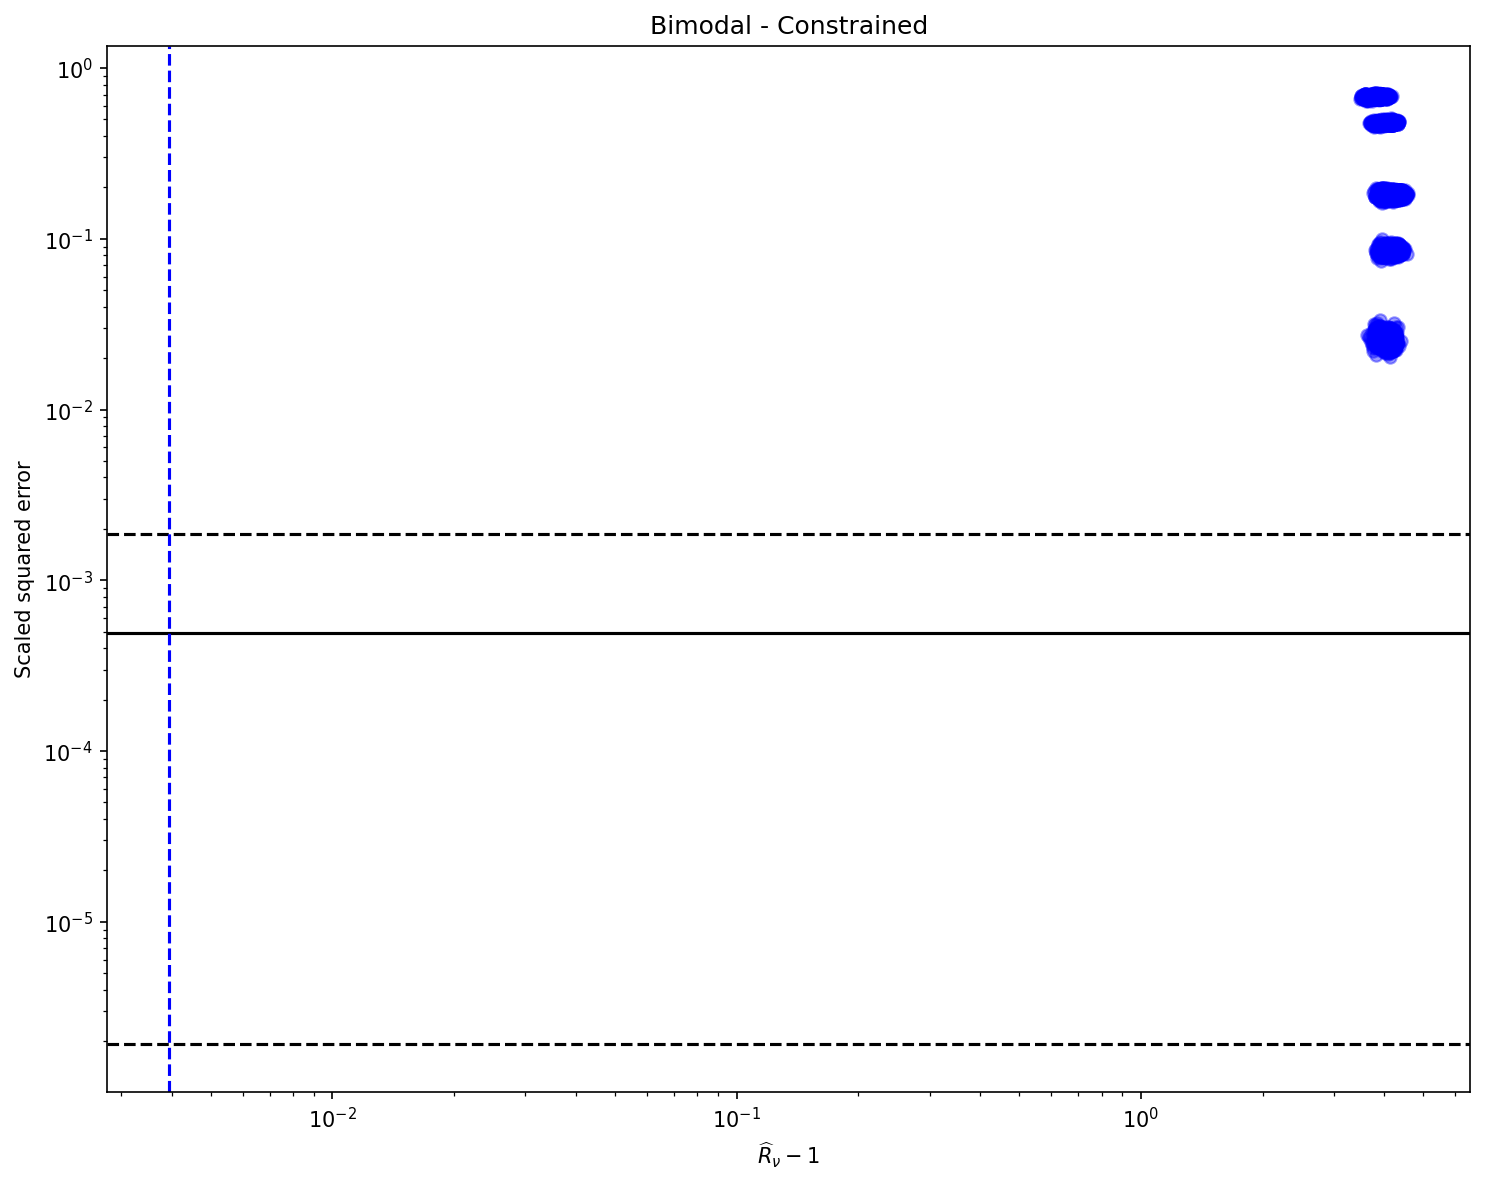

In [48]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Bimodal", False, bound, threshold,num_chains_short)

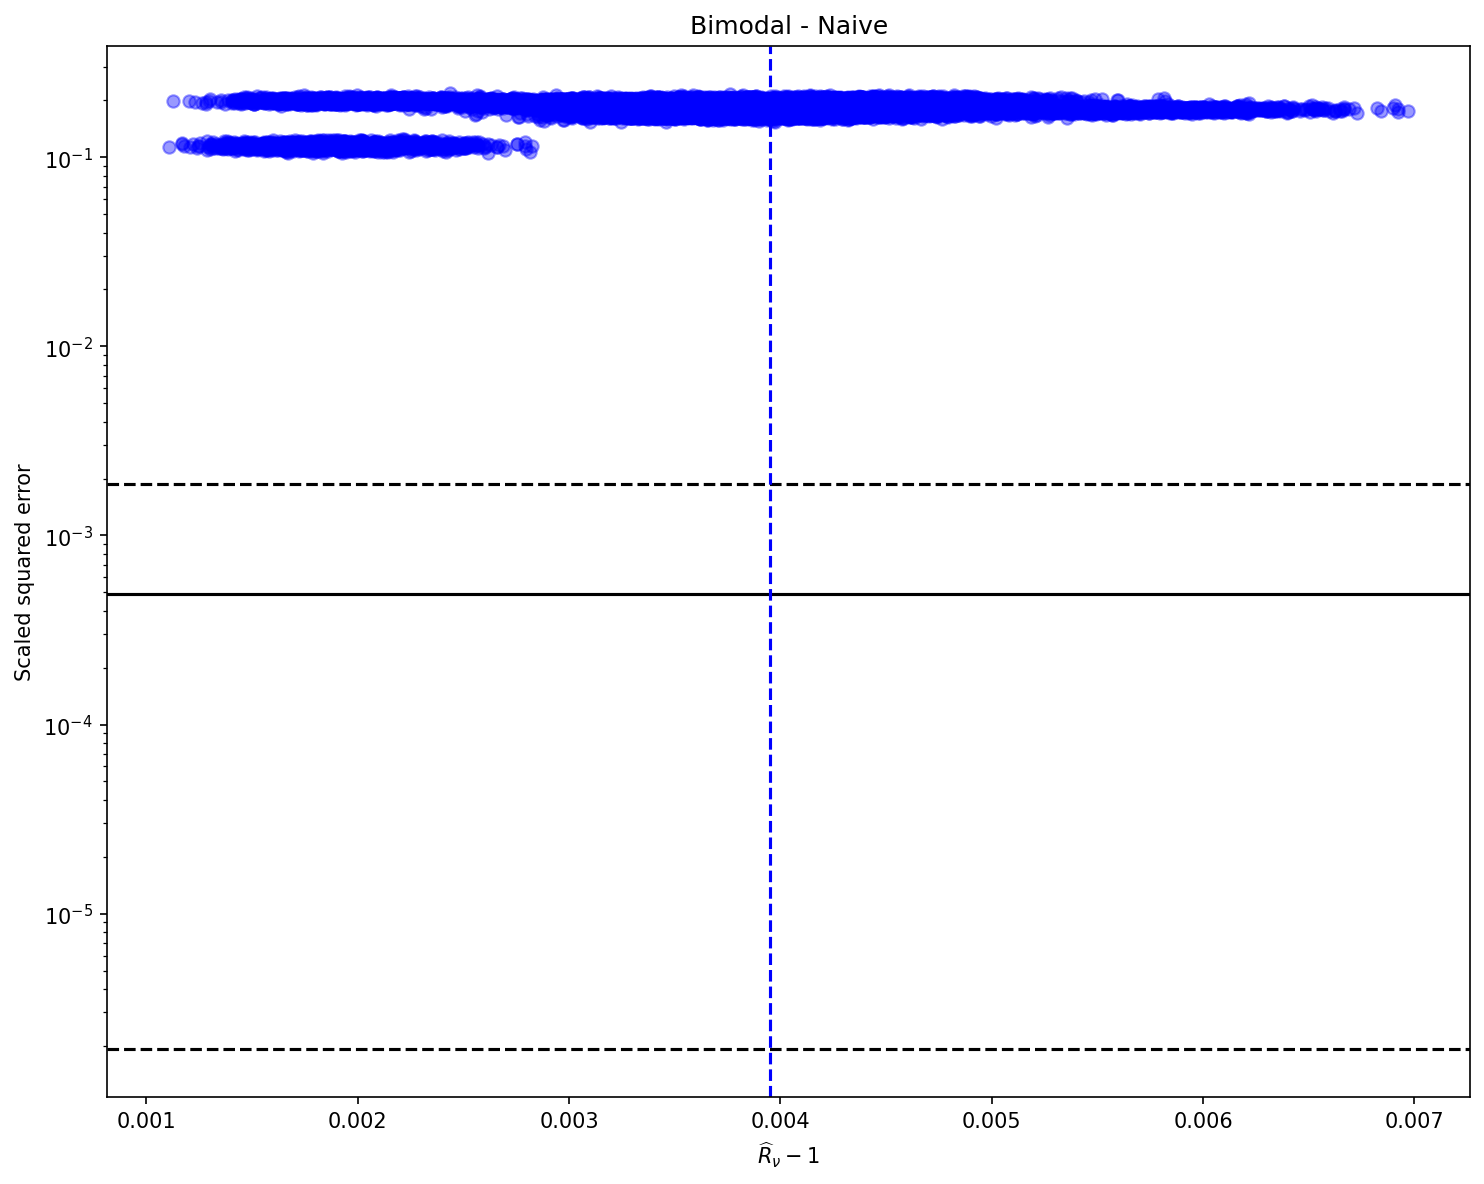

In [49]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Bimodal", True, bound, threshold,num_chains_short)

*Enhanced Plots: multiple line plots*

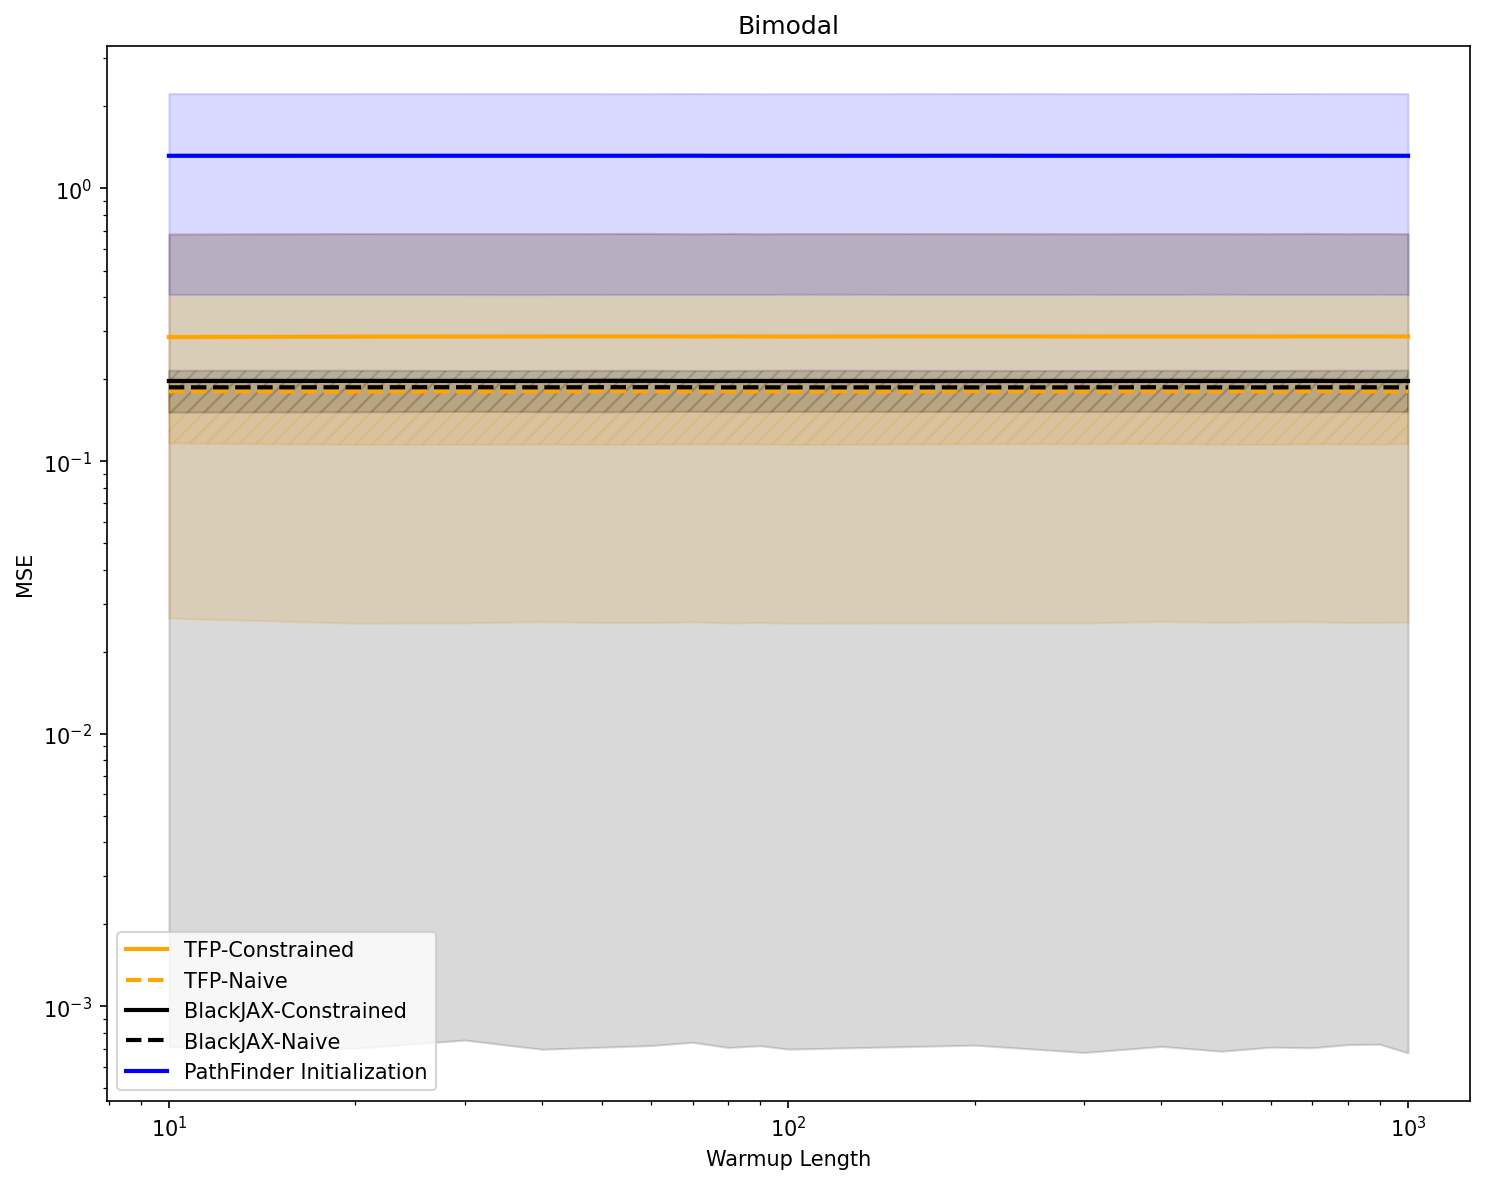

In [50]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_df, "Bimodal")

*Enhanced Plots: colored Scatter Plots*

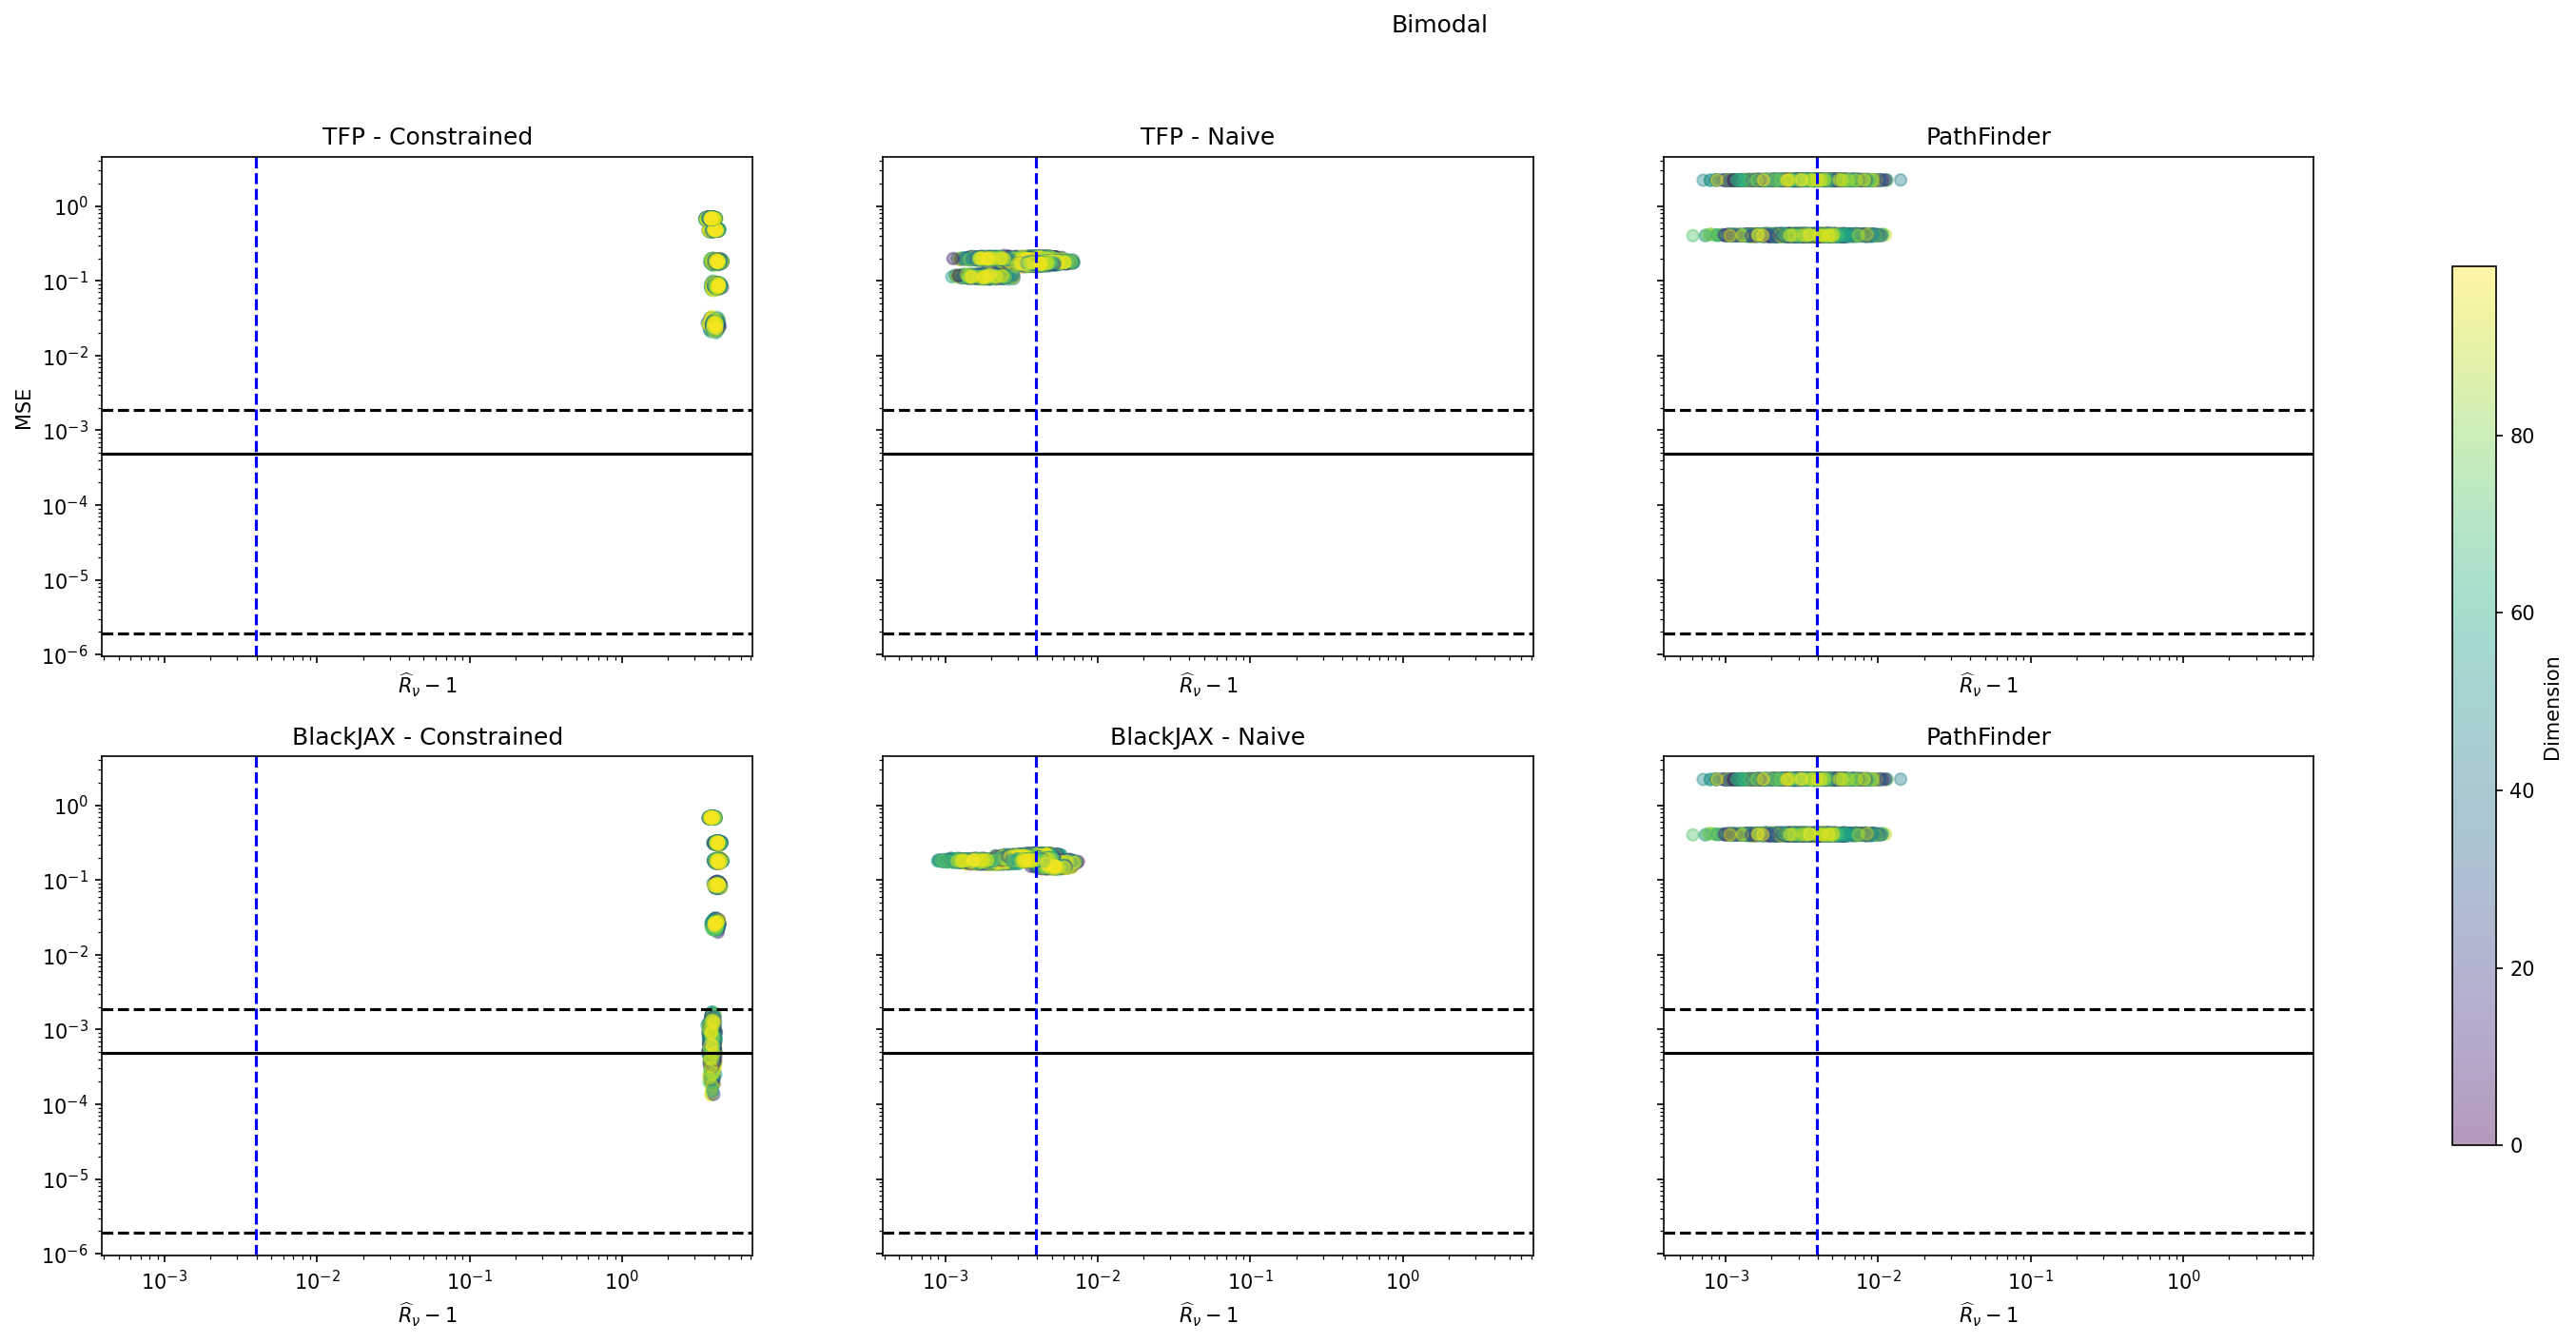

In [51]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Bimodal",bound, threshold,num_chains_short,"Dimension")

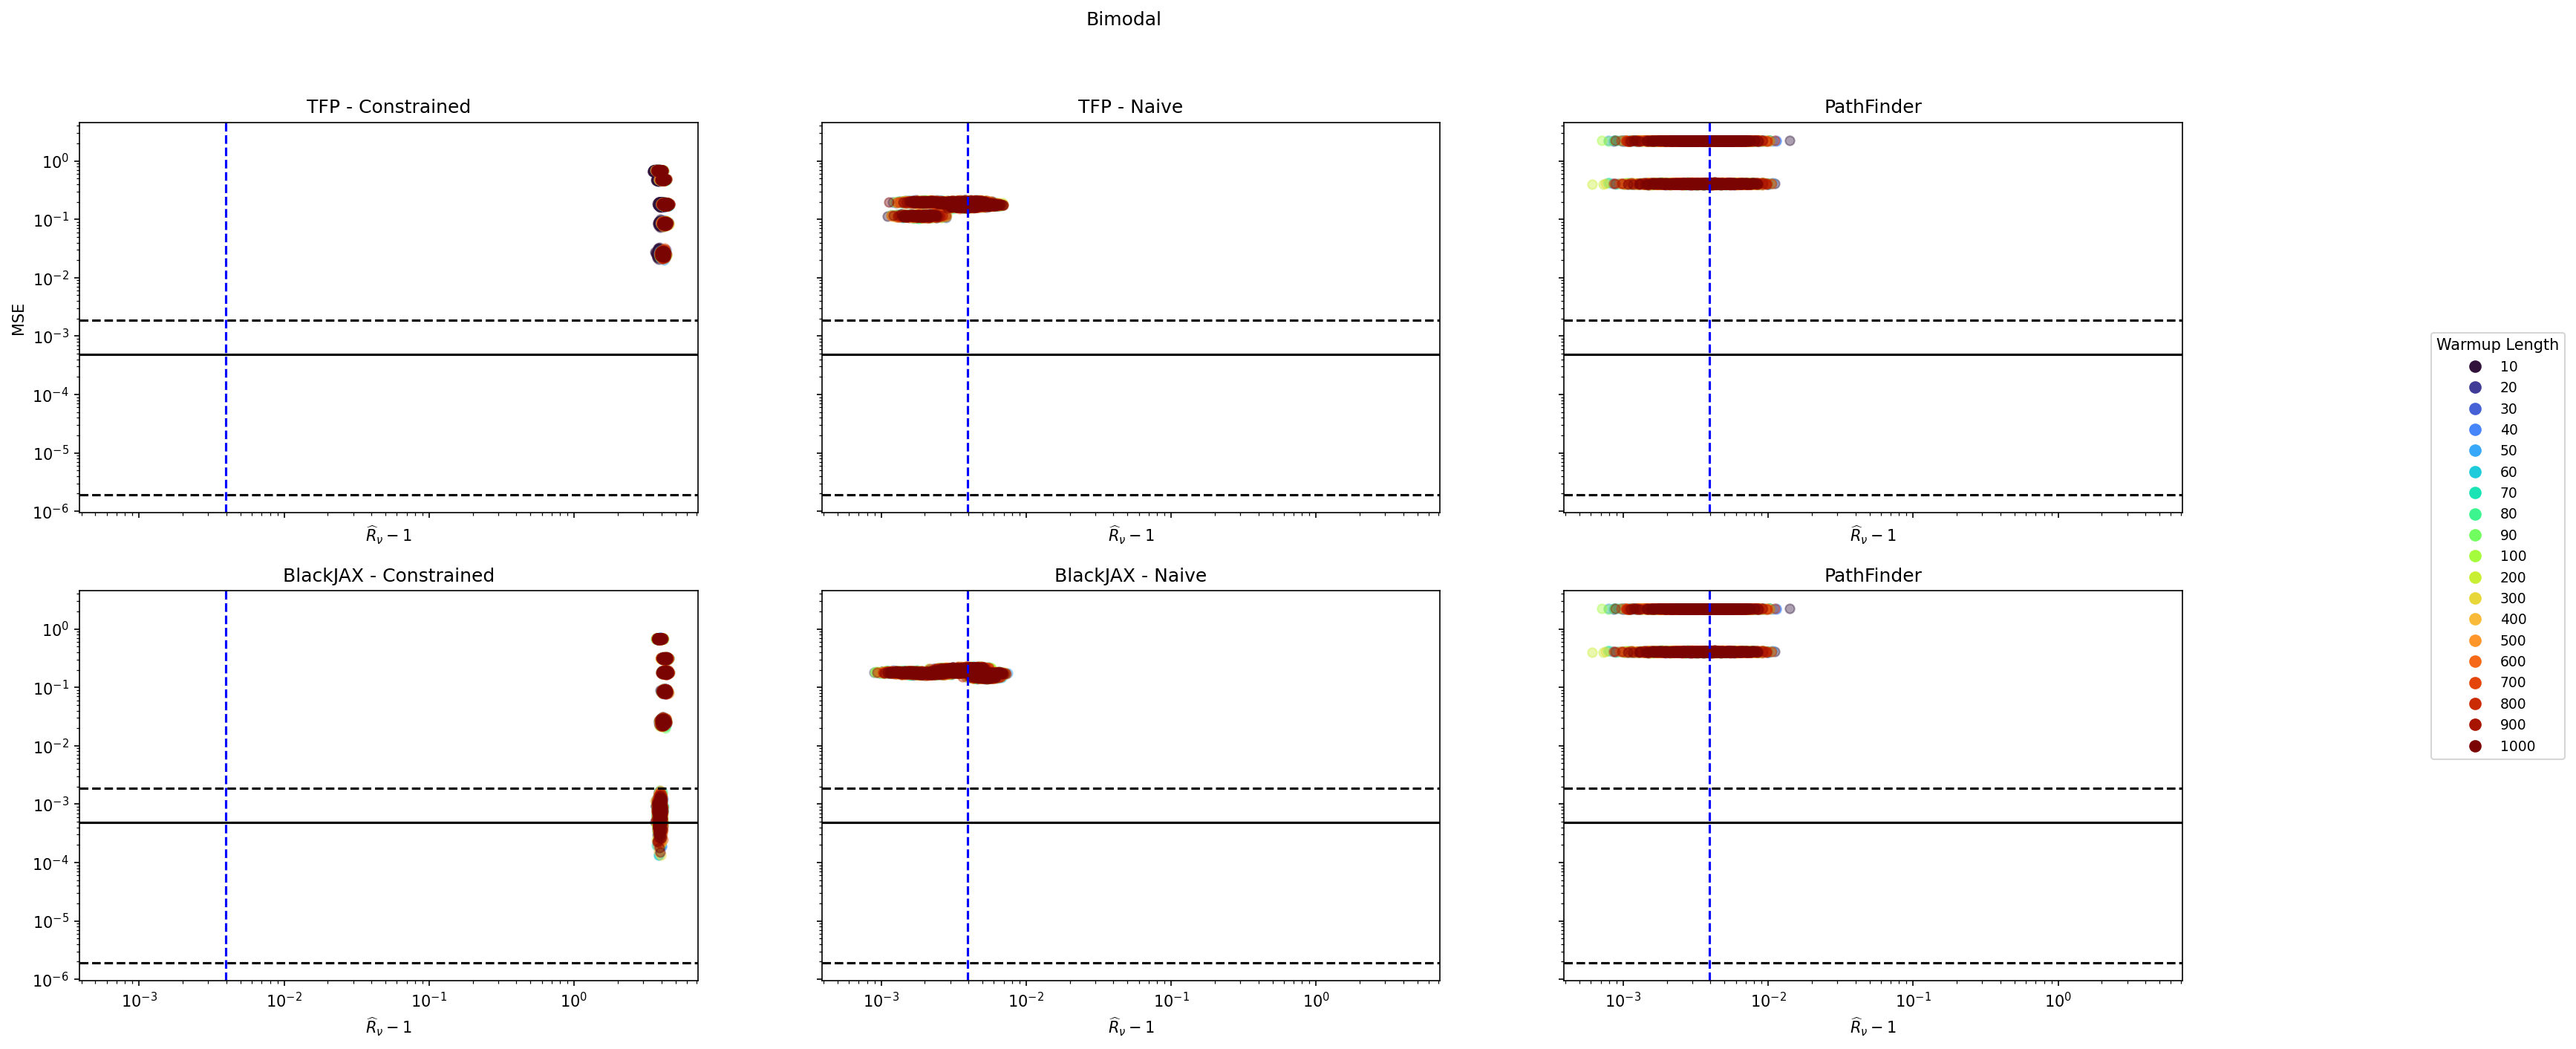

In [52]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Bimodal",bound, threshold,num_chains_short,"Warmup Length")

**Eight Schools Example**

In [53]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# MSE vs Warmups:
pf_MSE_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_MSE.pkl"
pf_MSE_df = pd.read_pickle(pf_MSE_path)
# MSE vs nested Rhat:
pf_R_Hat_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_R_Hat.pkl"
pf_R_Hat_df = pd.read_pickle(pf_R_Hat_path)

*Original Paper: line plot*

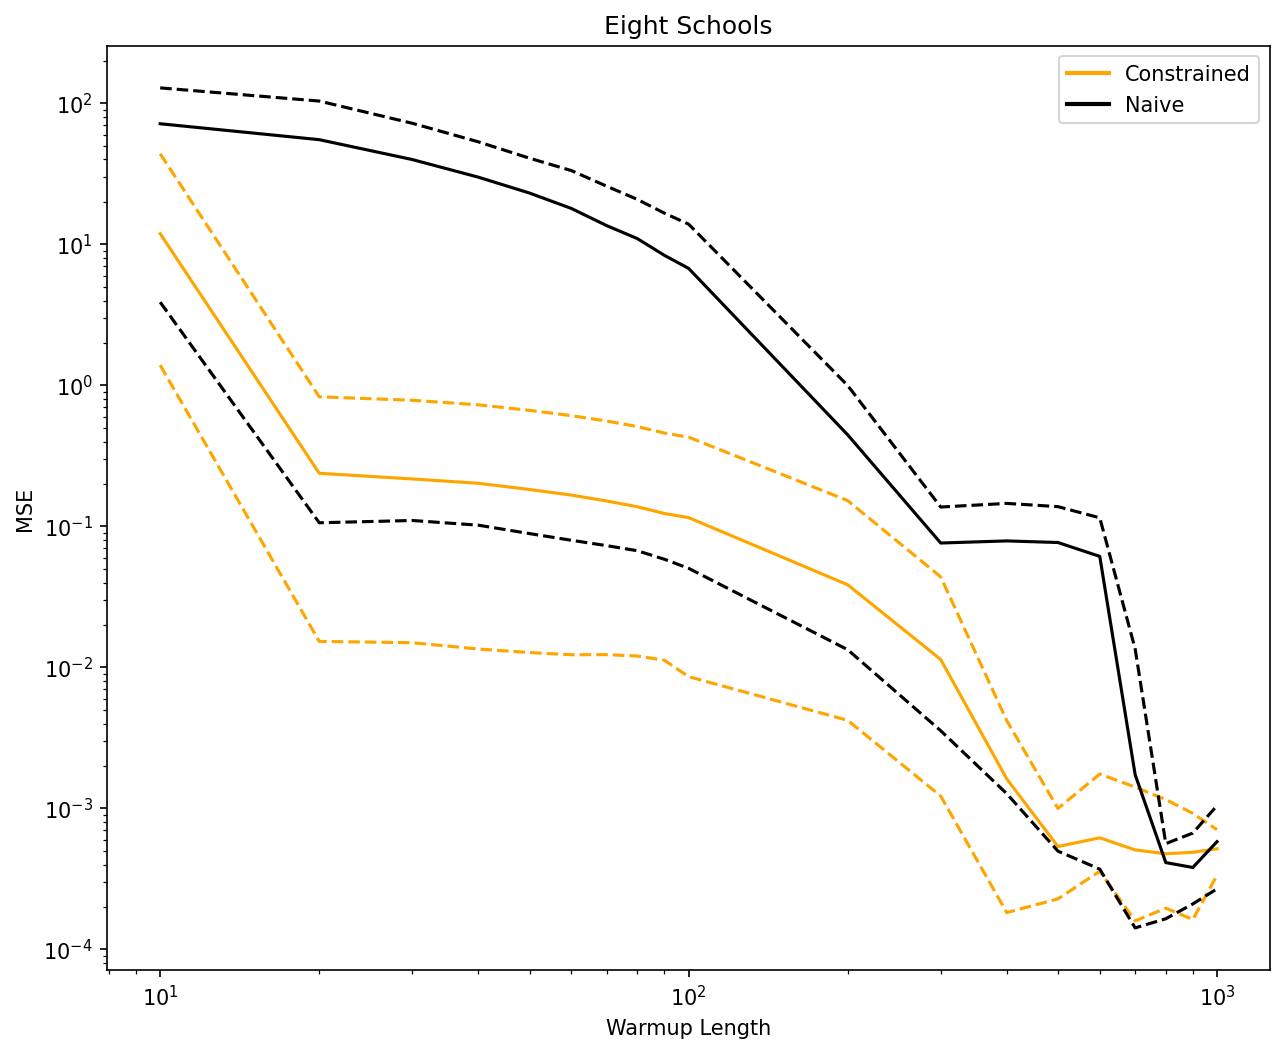

In [54]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Eight Schools")

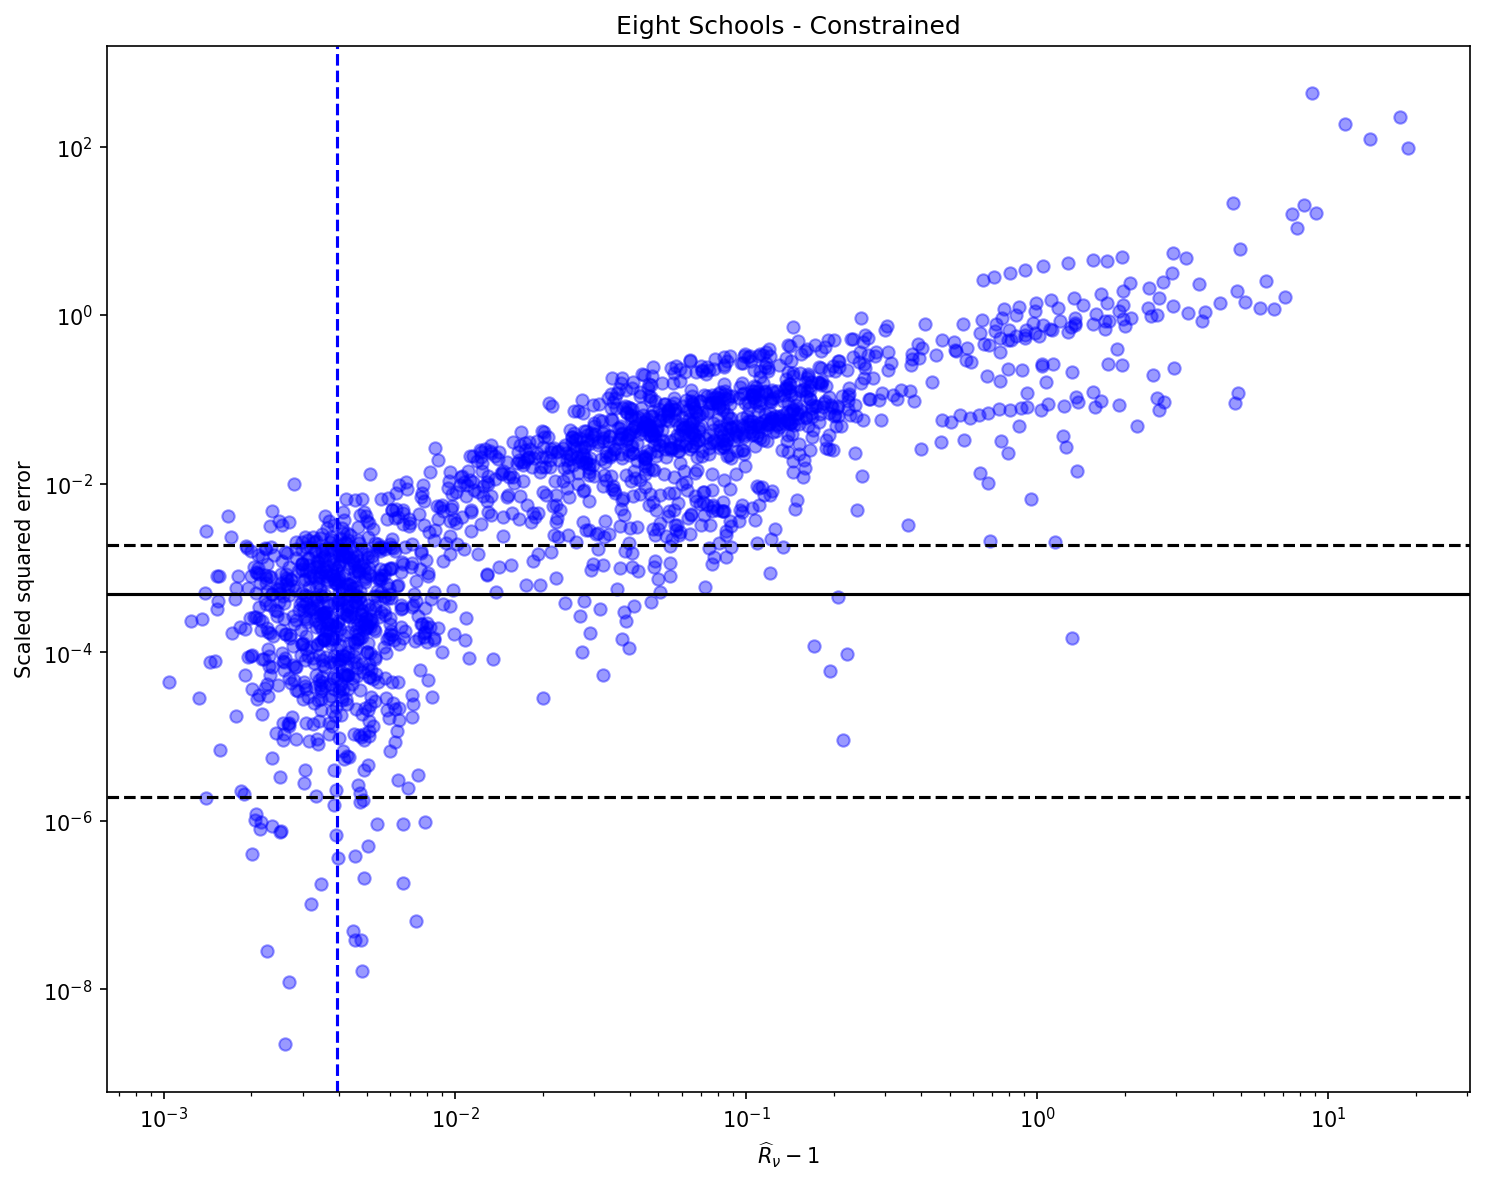

In [55]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Eight Schools", False, bound, threshold,num_chains_short)

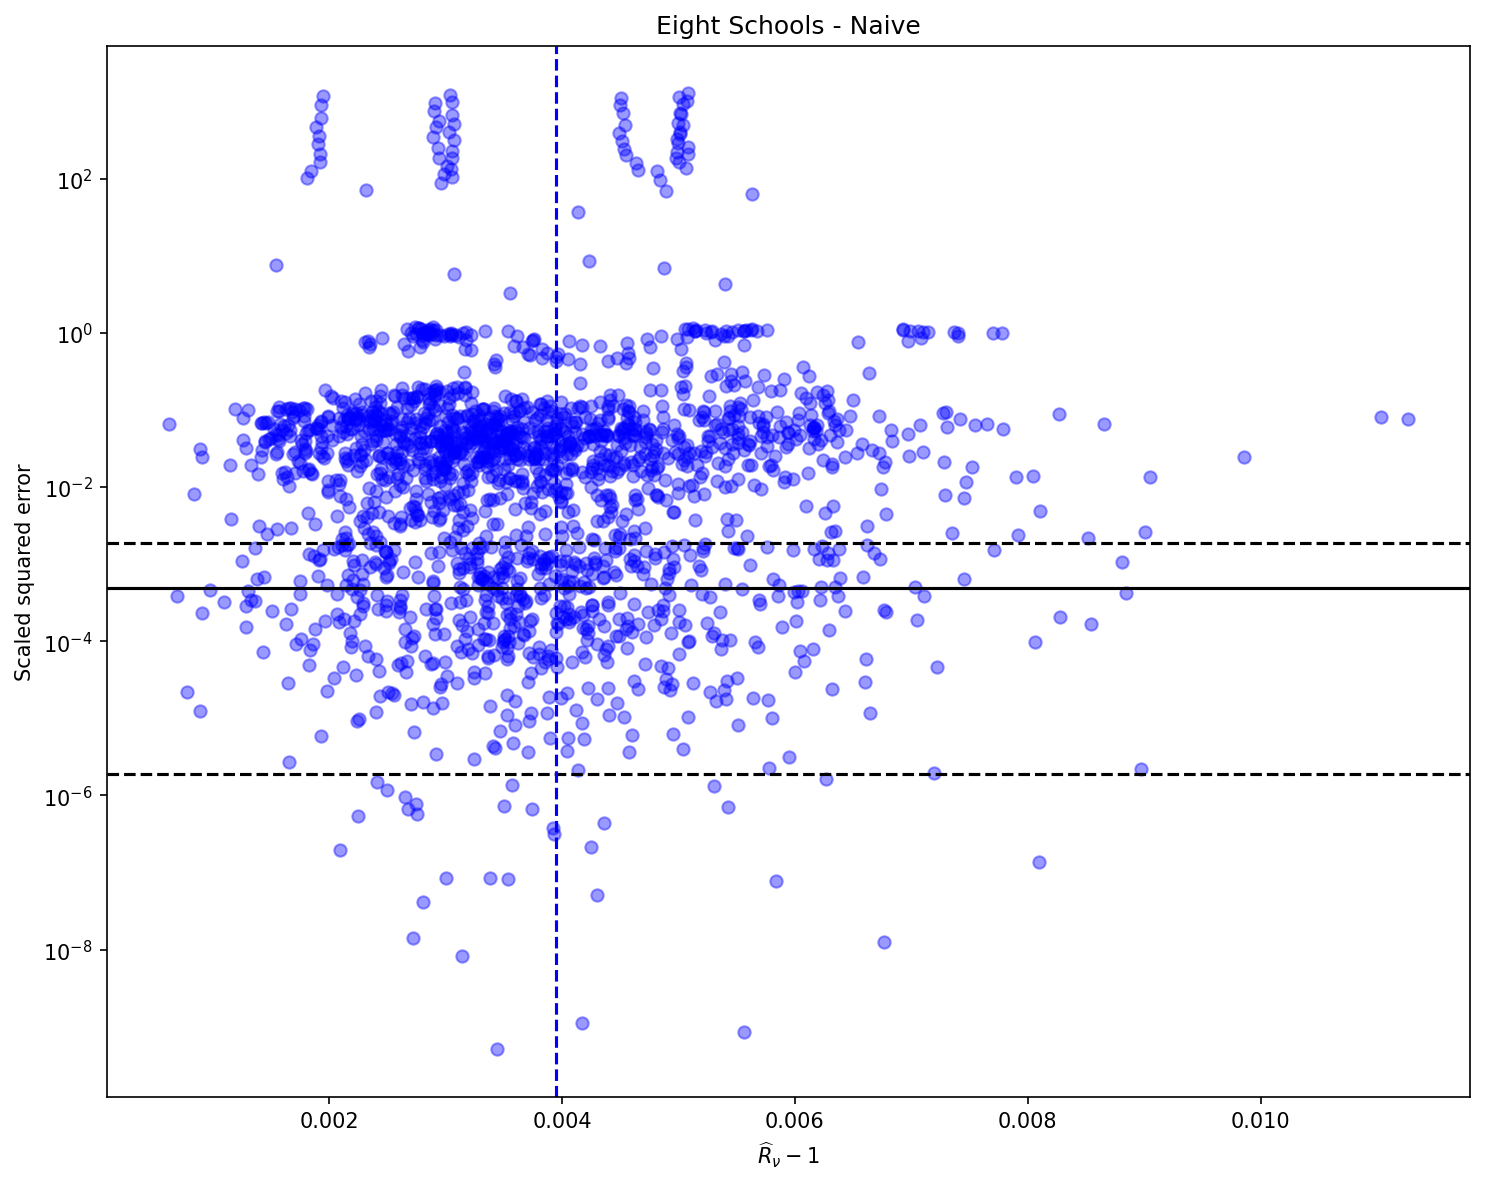

In [57]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Eight Schools", True, bound, threshold,num_chains_short)

*Enhanced Plots: multiple line plots*

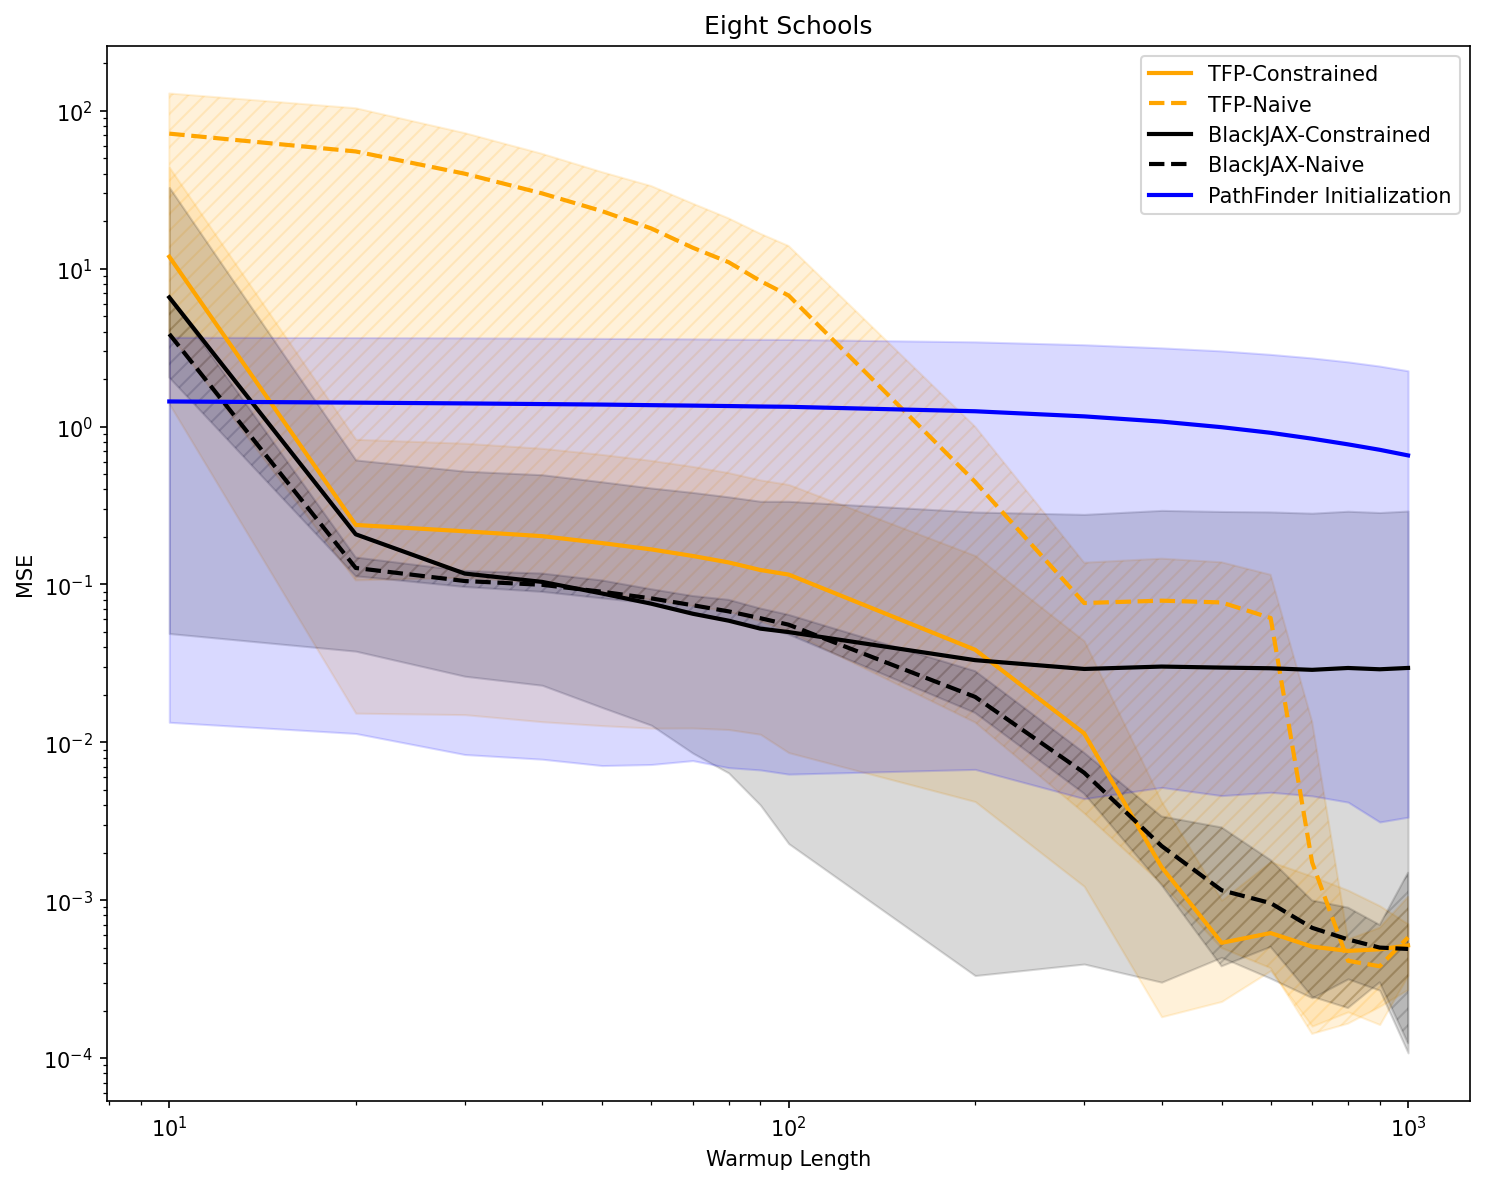

In [58]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_df, "Eight Schools")

*Enhanced Plots: colored Scatter Plots*

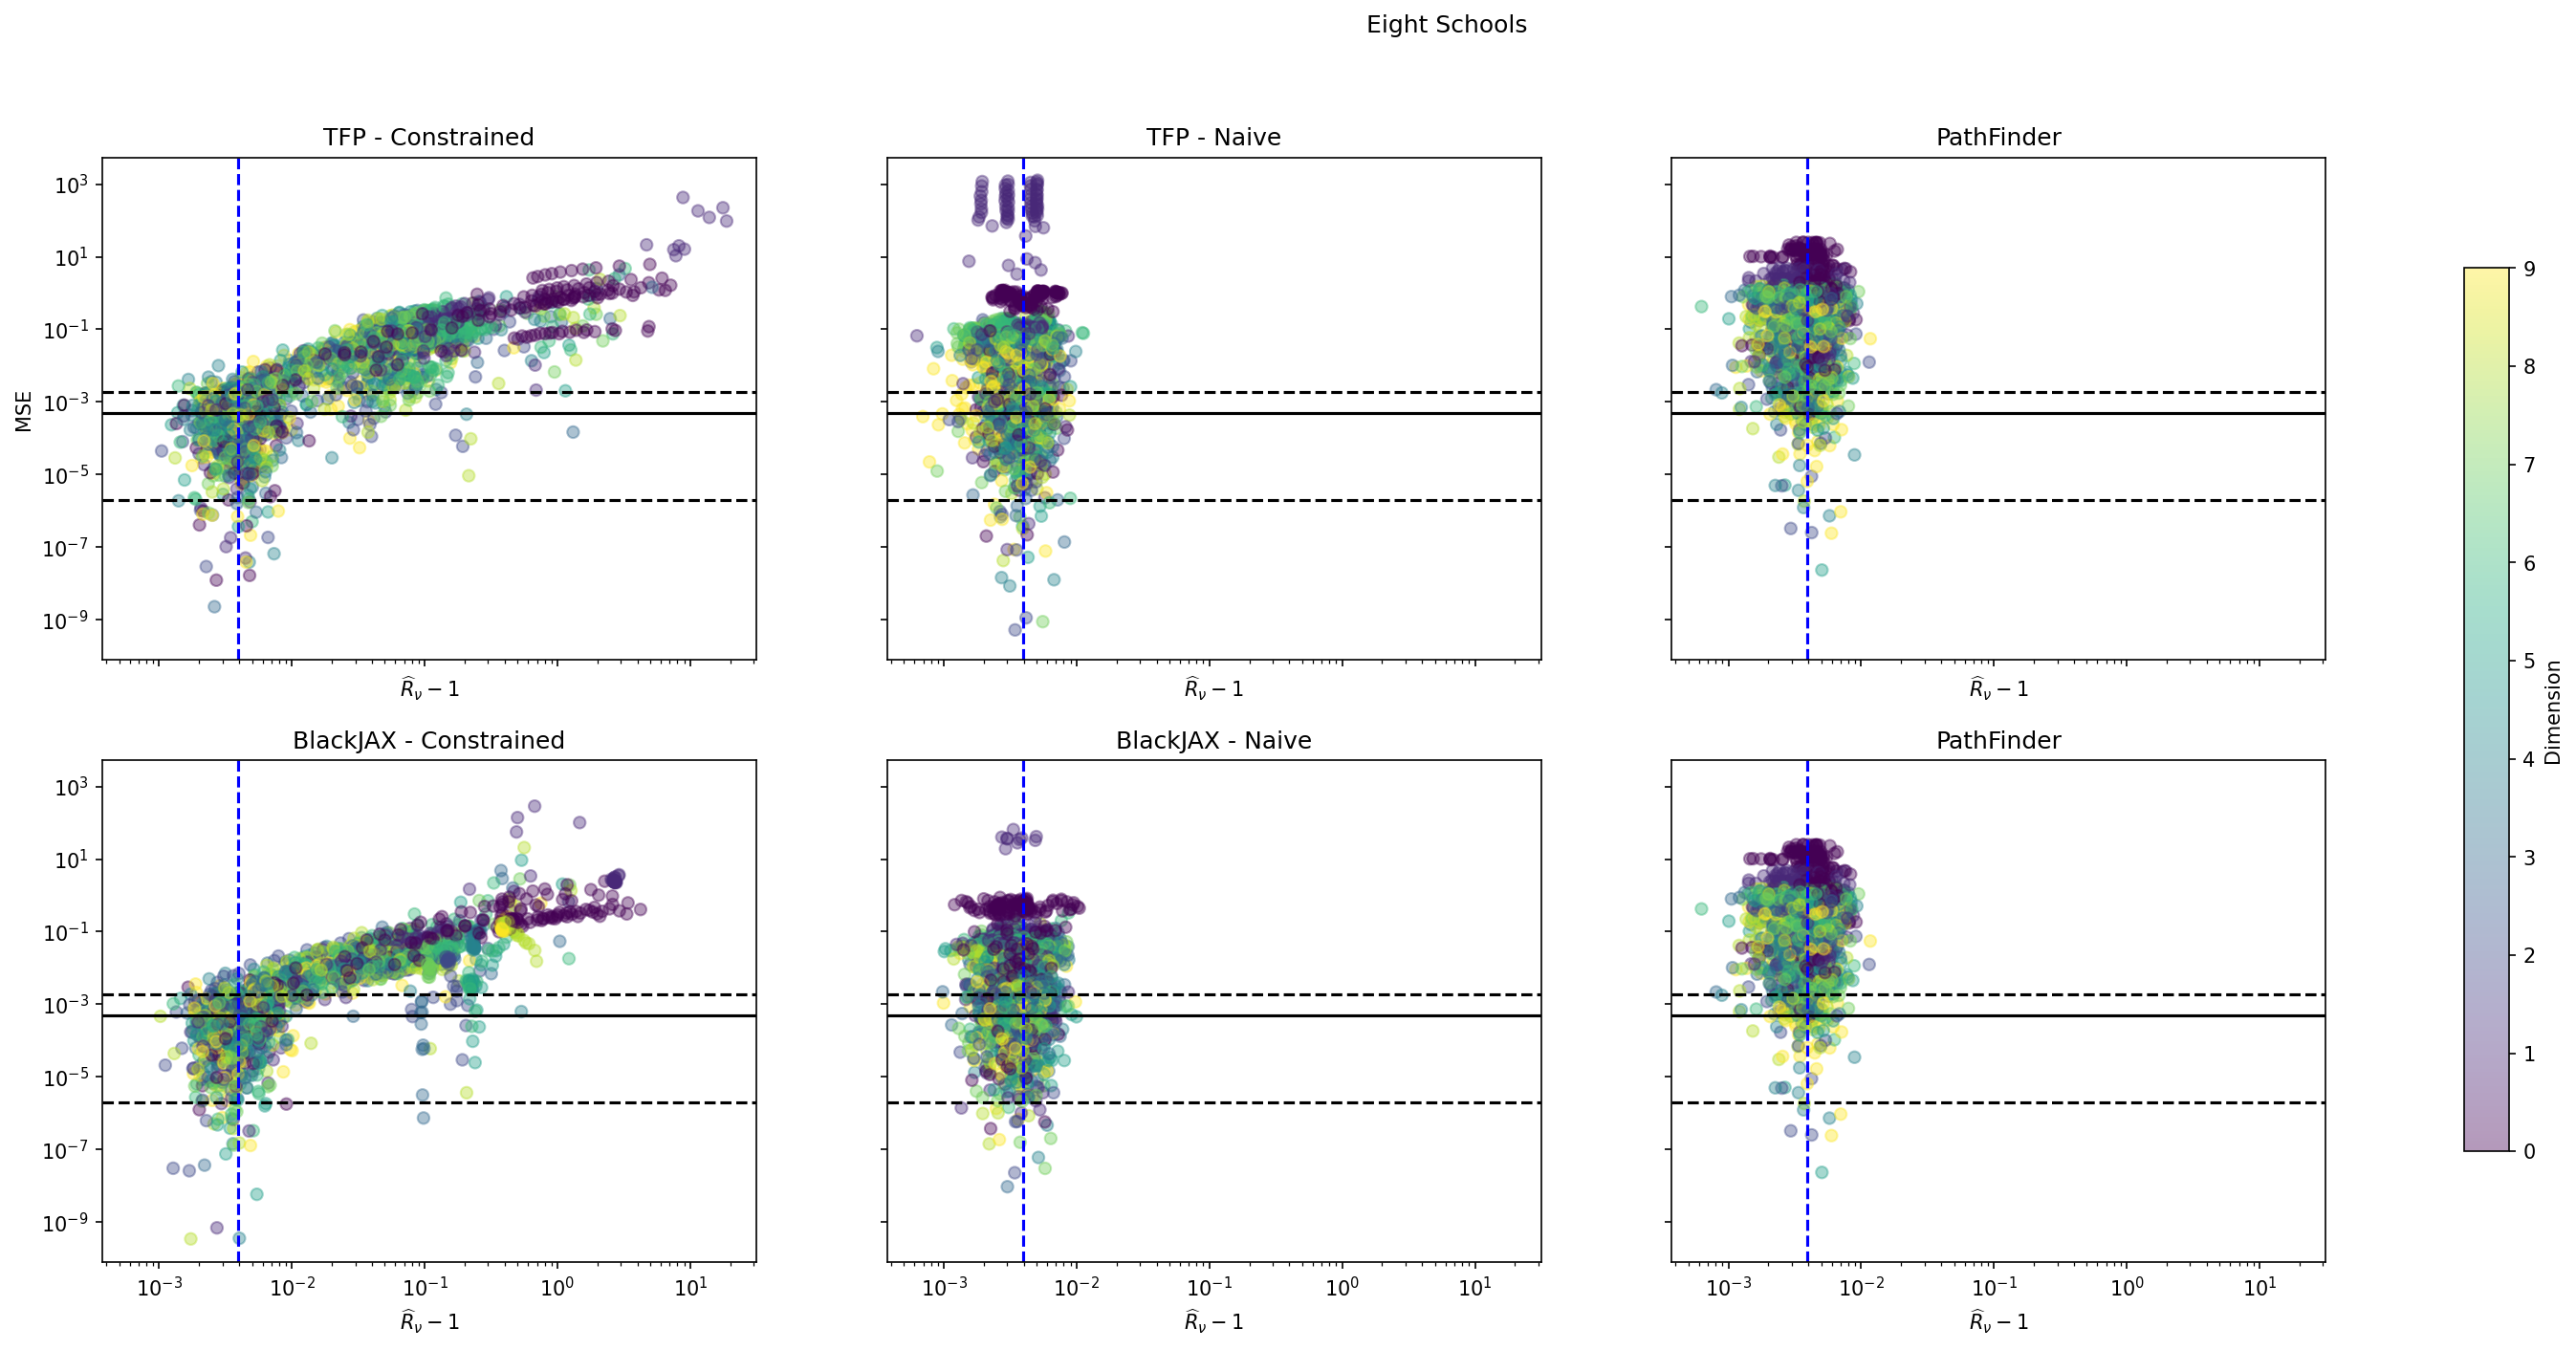

In [59]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Eight Schools",bound, threshold,num_chains_short,"Dimension")

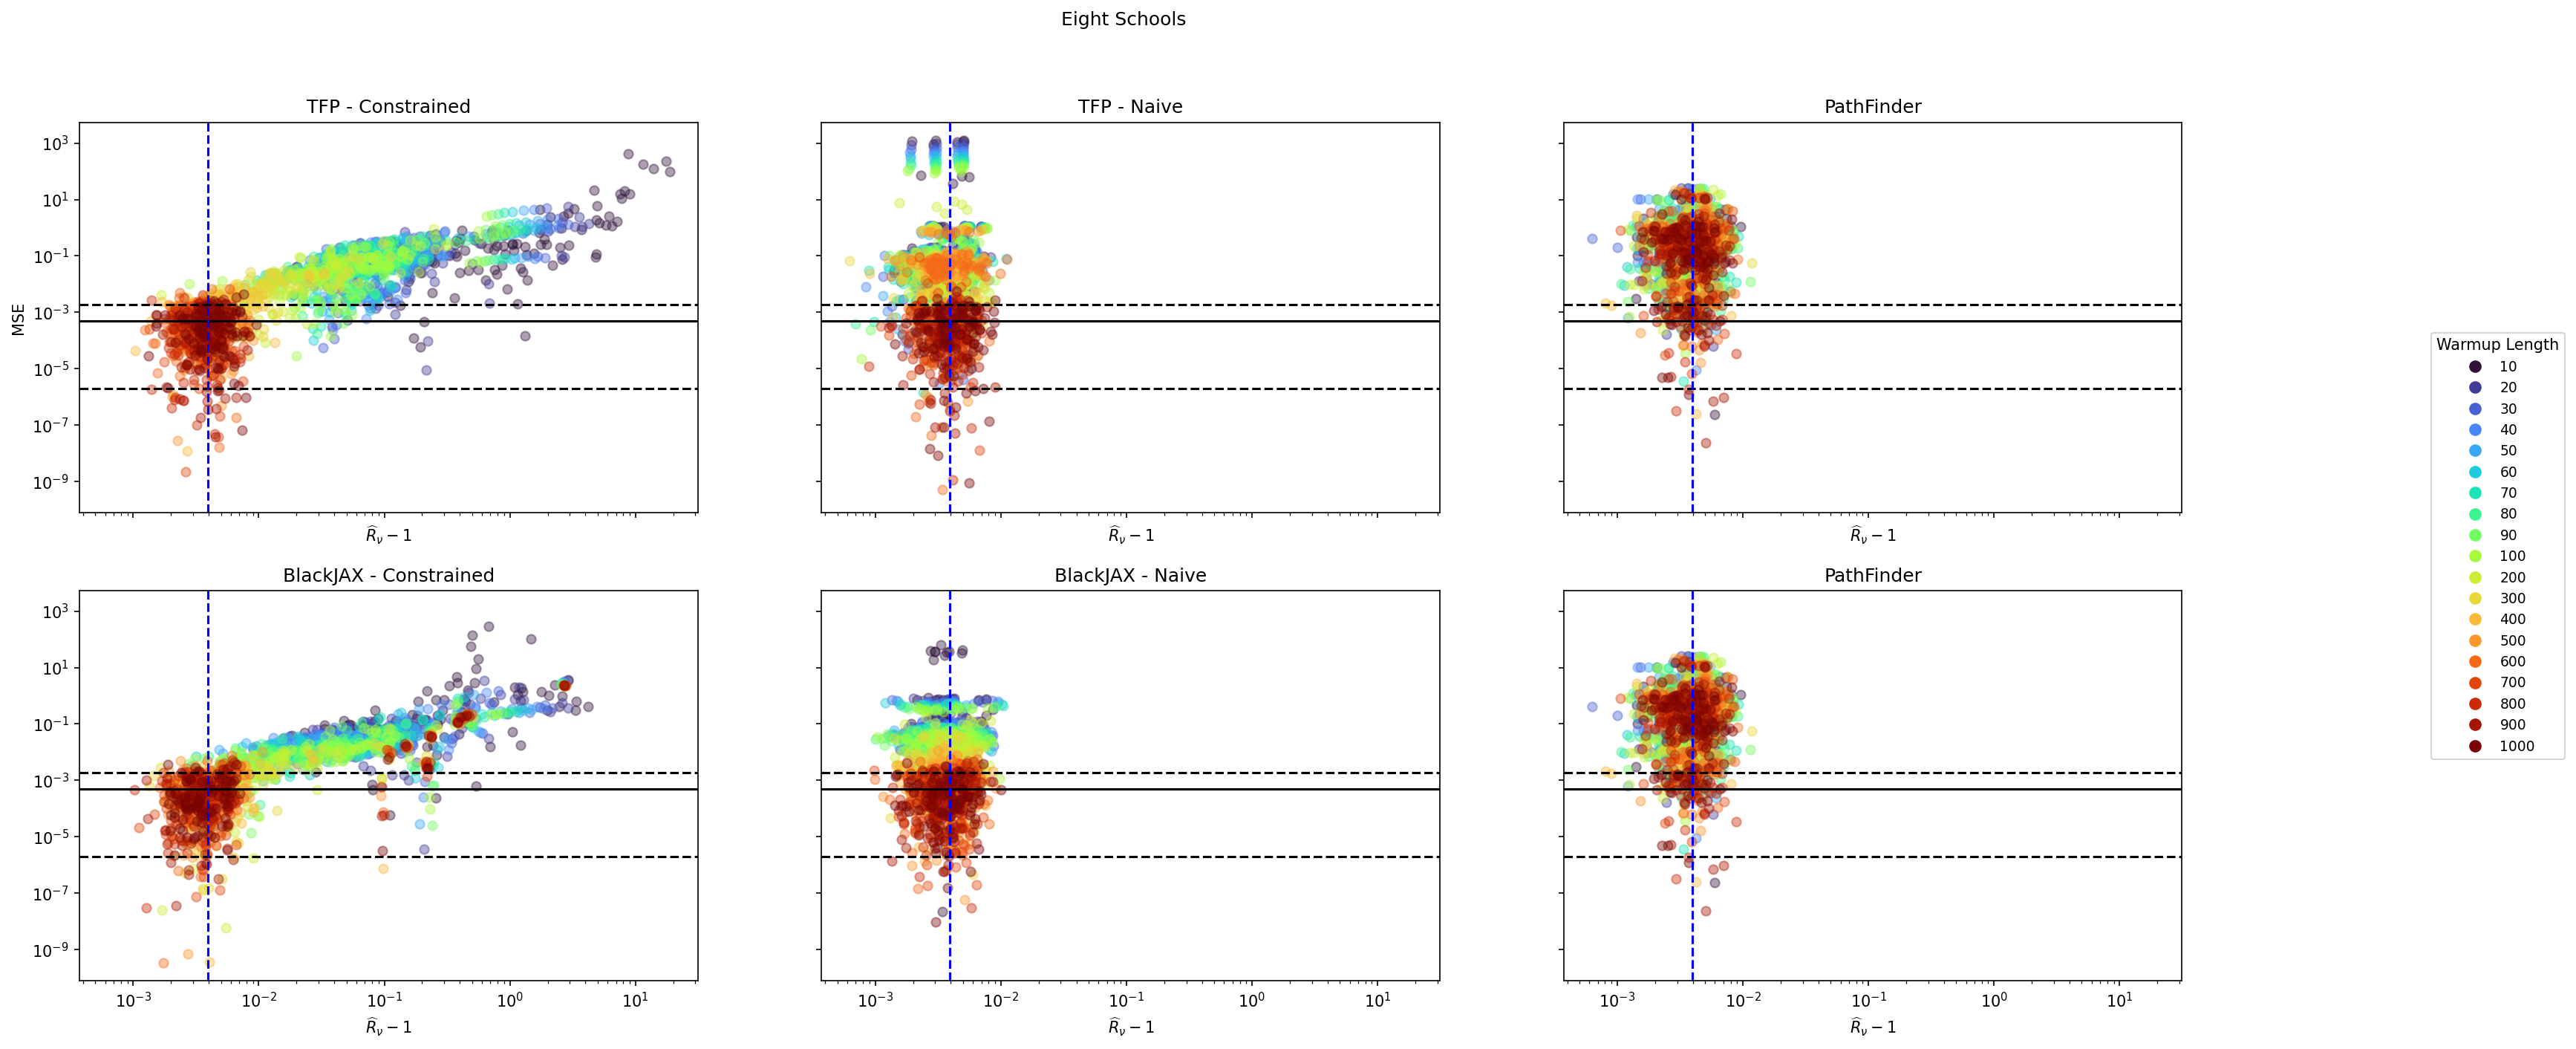

In [60]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Eight Schools",bound, threshold,num_chains_short,"Warmup Length")

**Item Response Theory Example**

In [61]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# MSE vs Warmups:
pf_MSE_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/IRT_MSE.pkl"
pf_MSE_df = pd.read_pickle(pf_MSE_path)
# MSE vs nested Rhat:
pf_R_Hat_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/IRT_R_Hat.pkl"
pf_R_Hat_df = pd.read_pickle(pf_R_Hat_path)
print("PathFinder implementation data Loaded!")

*Original Paper: line plot*

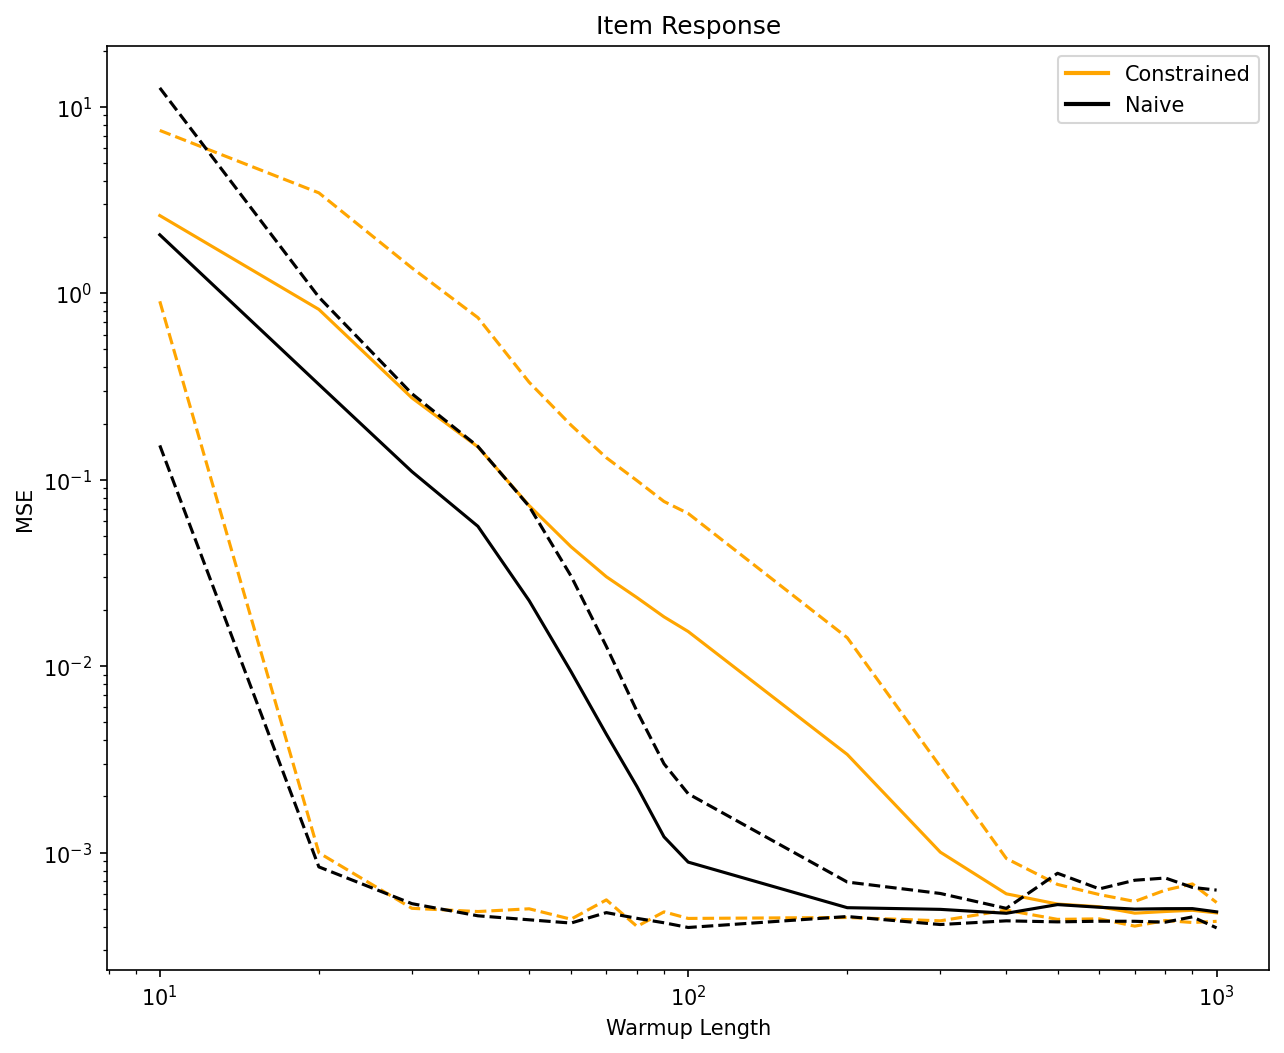

In [62]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Item Response")

*Original Paper: Scatter plot*

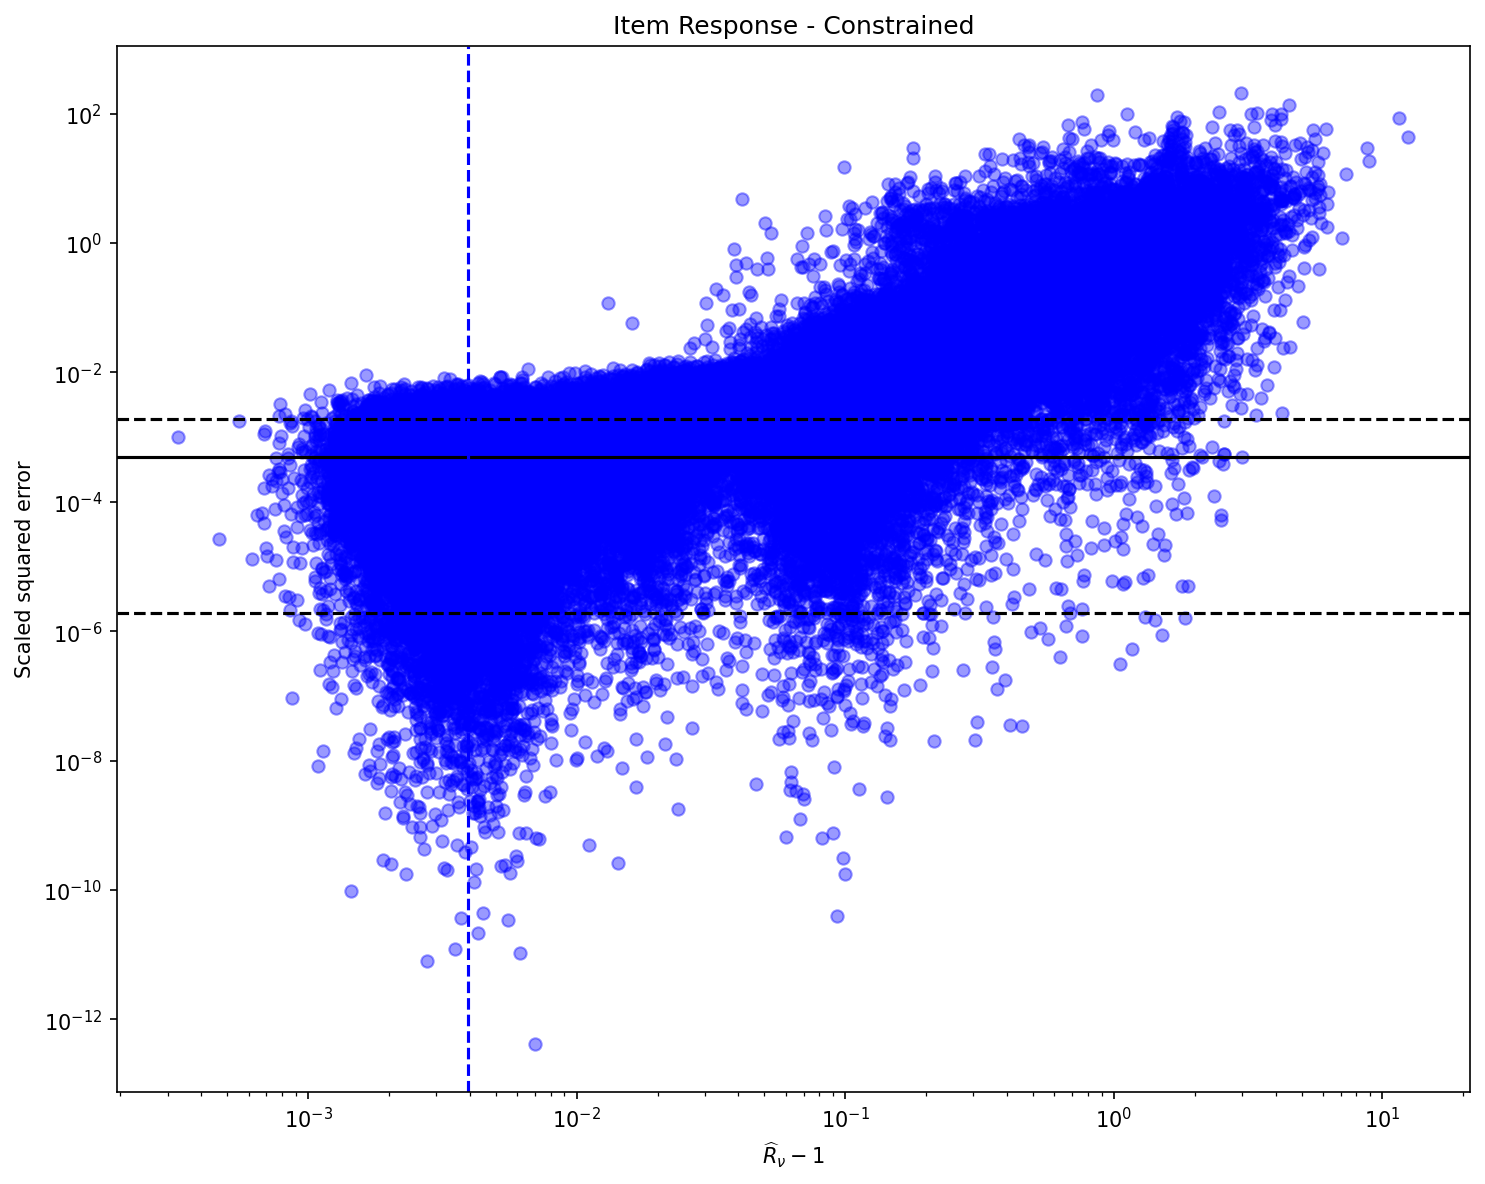

In [63]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Item Response", False, bound, threshold,num_chains_short)

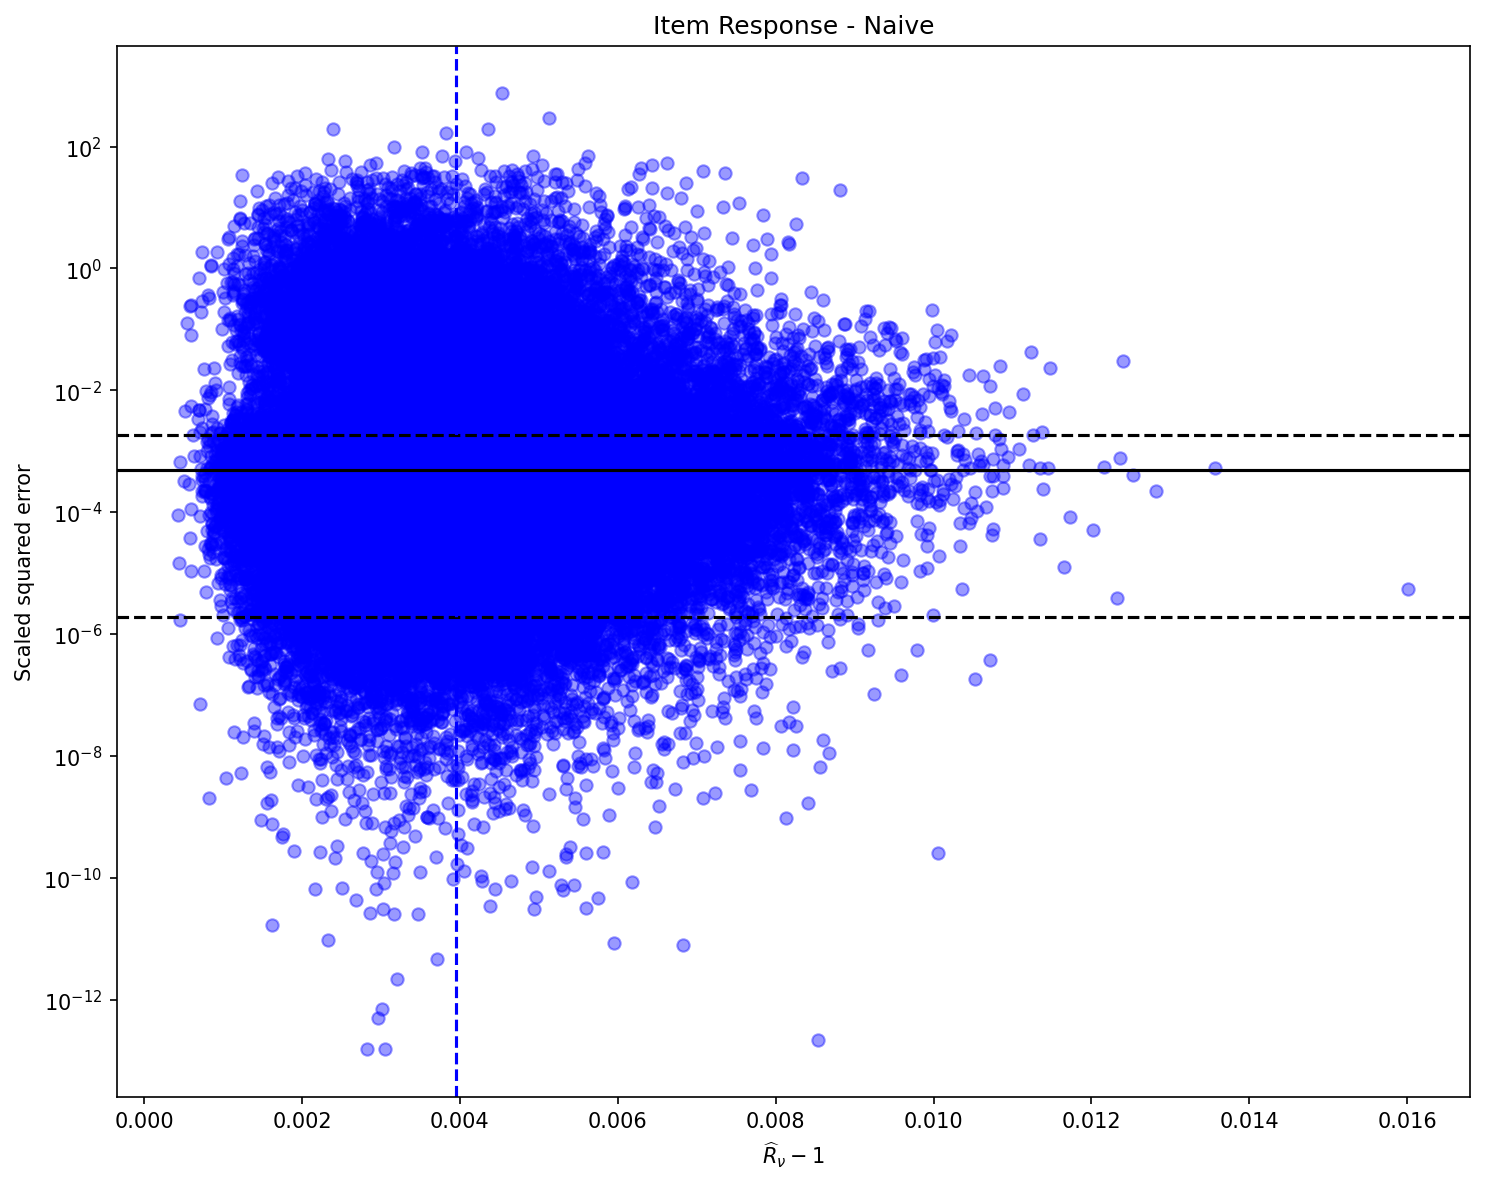

In [64]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Item Response", True, bound, threshold,num_chains_short)

*Enhanced Plots: multiple line plots*

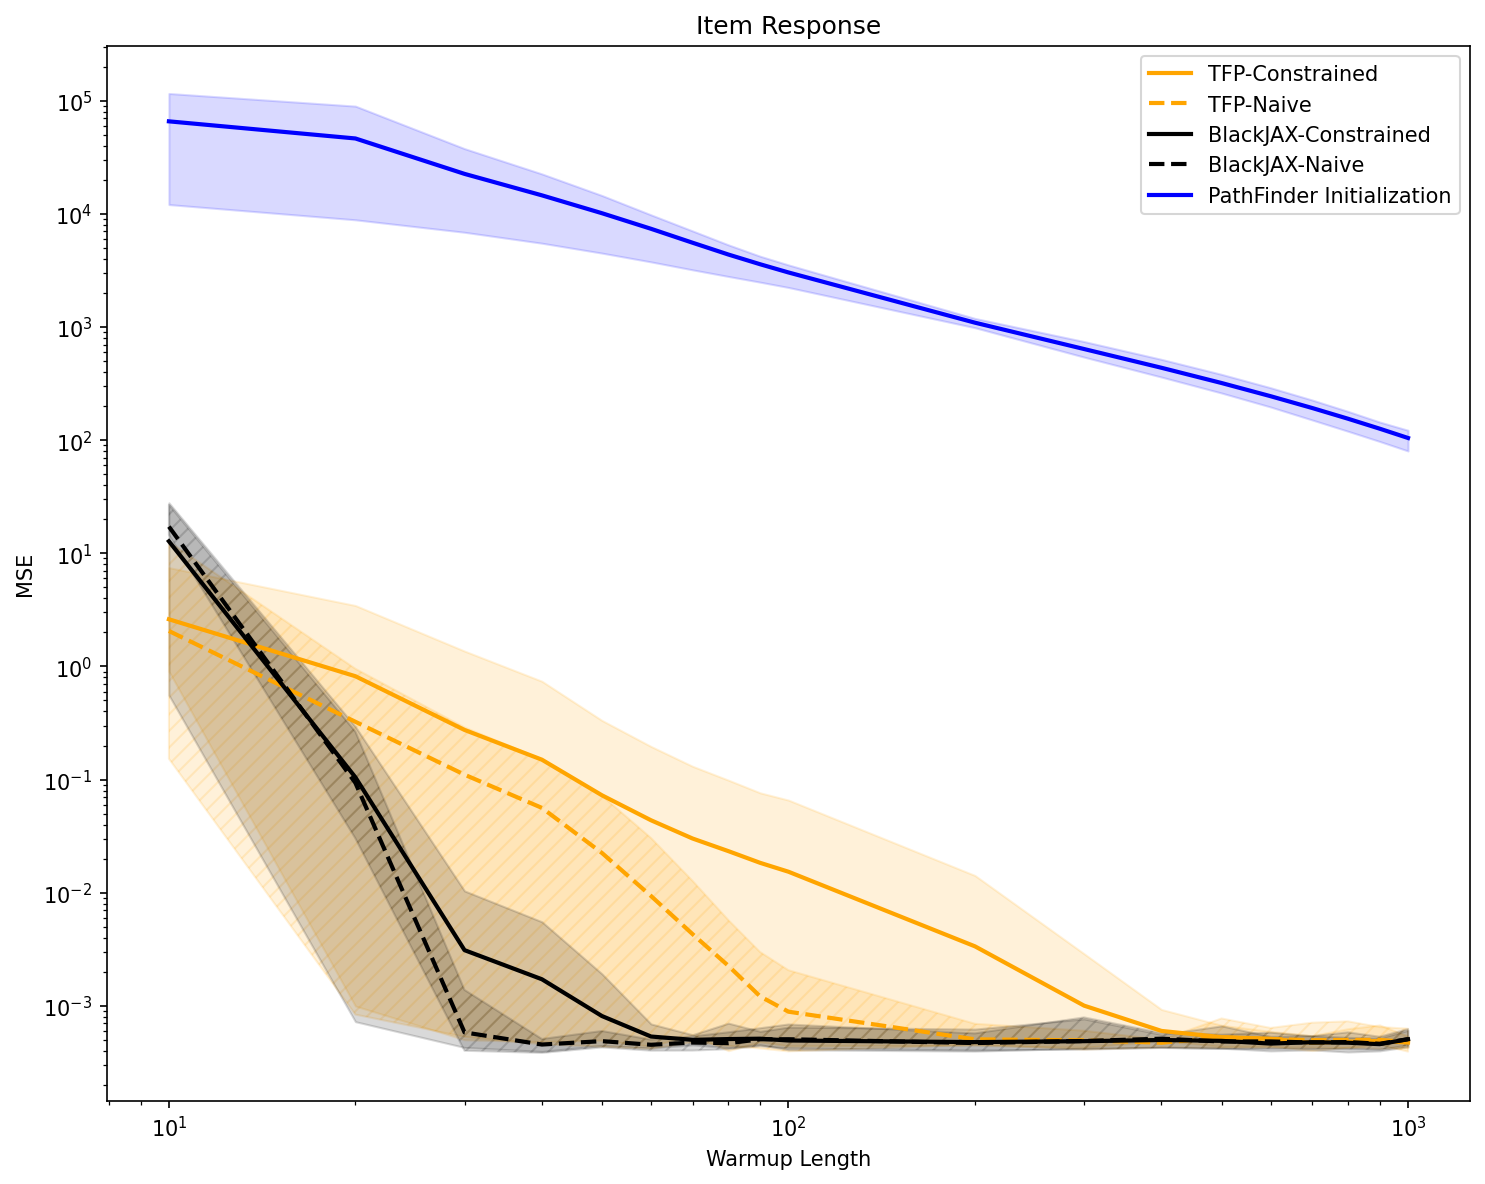

In [65]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_df, "Item Response")

*Enhanced Plots: colored Scatter Plots*

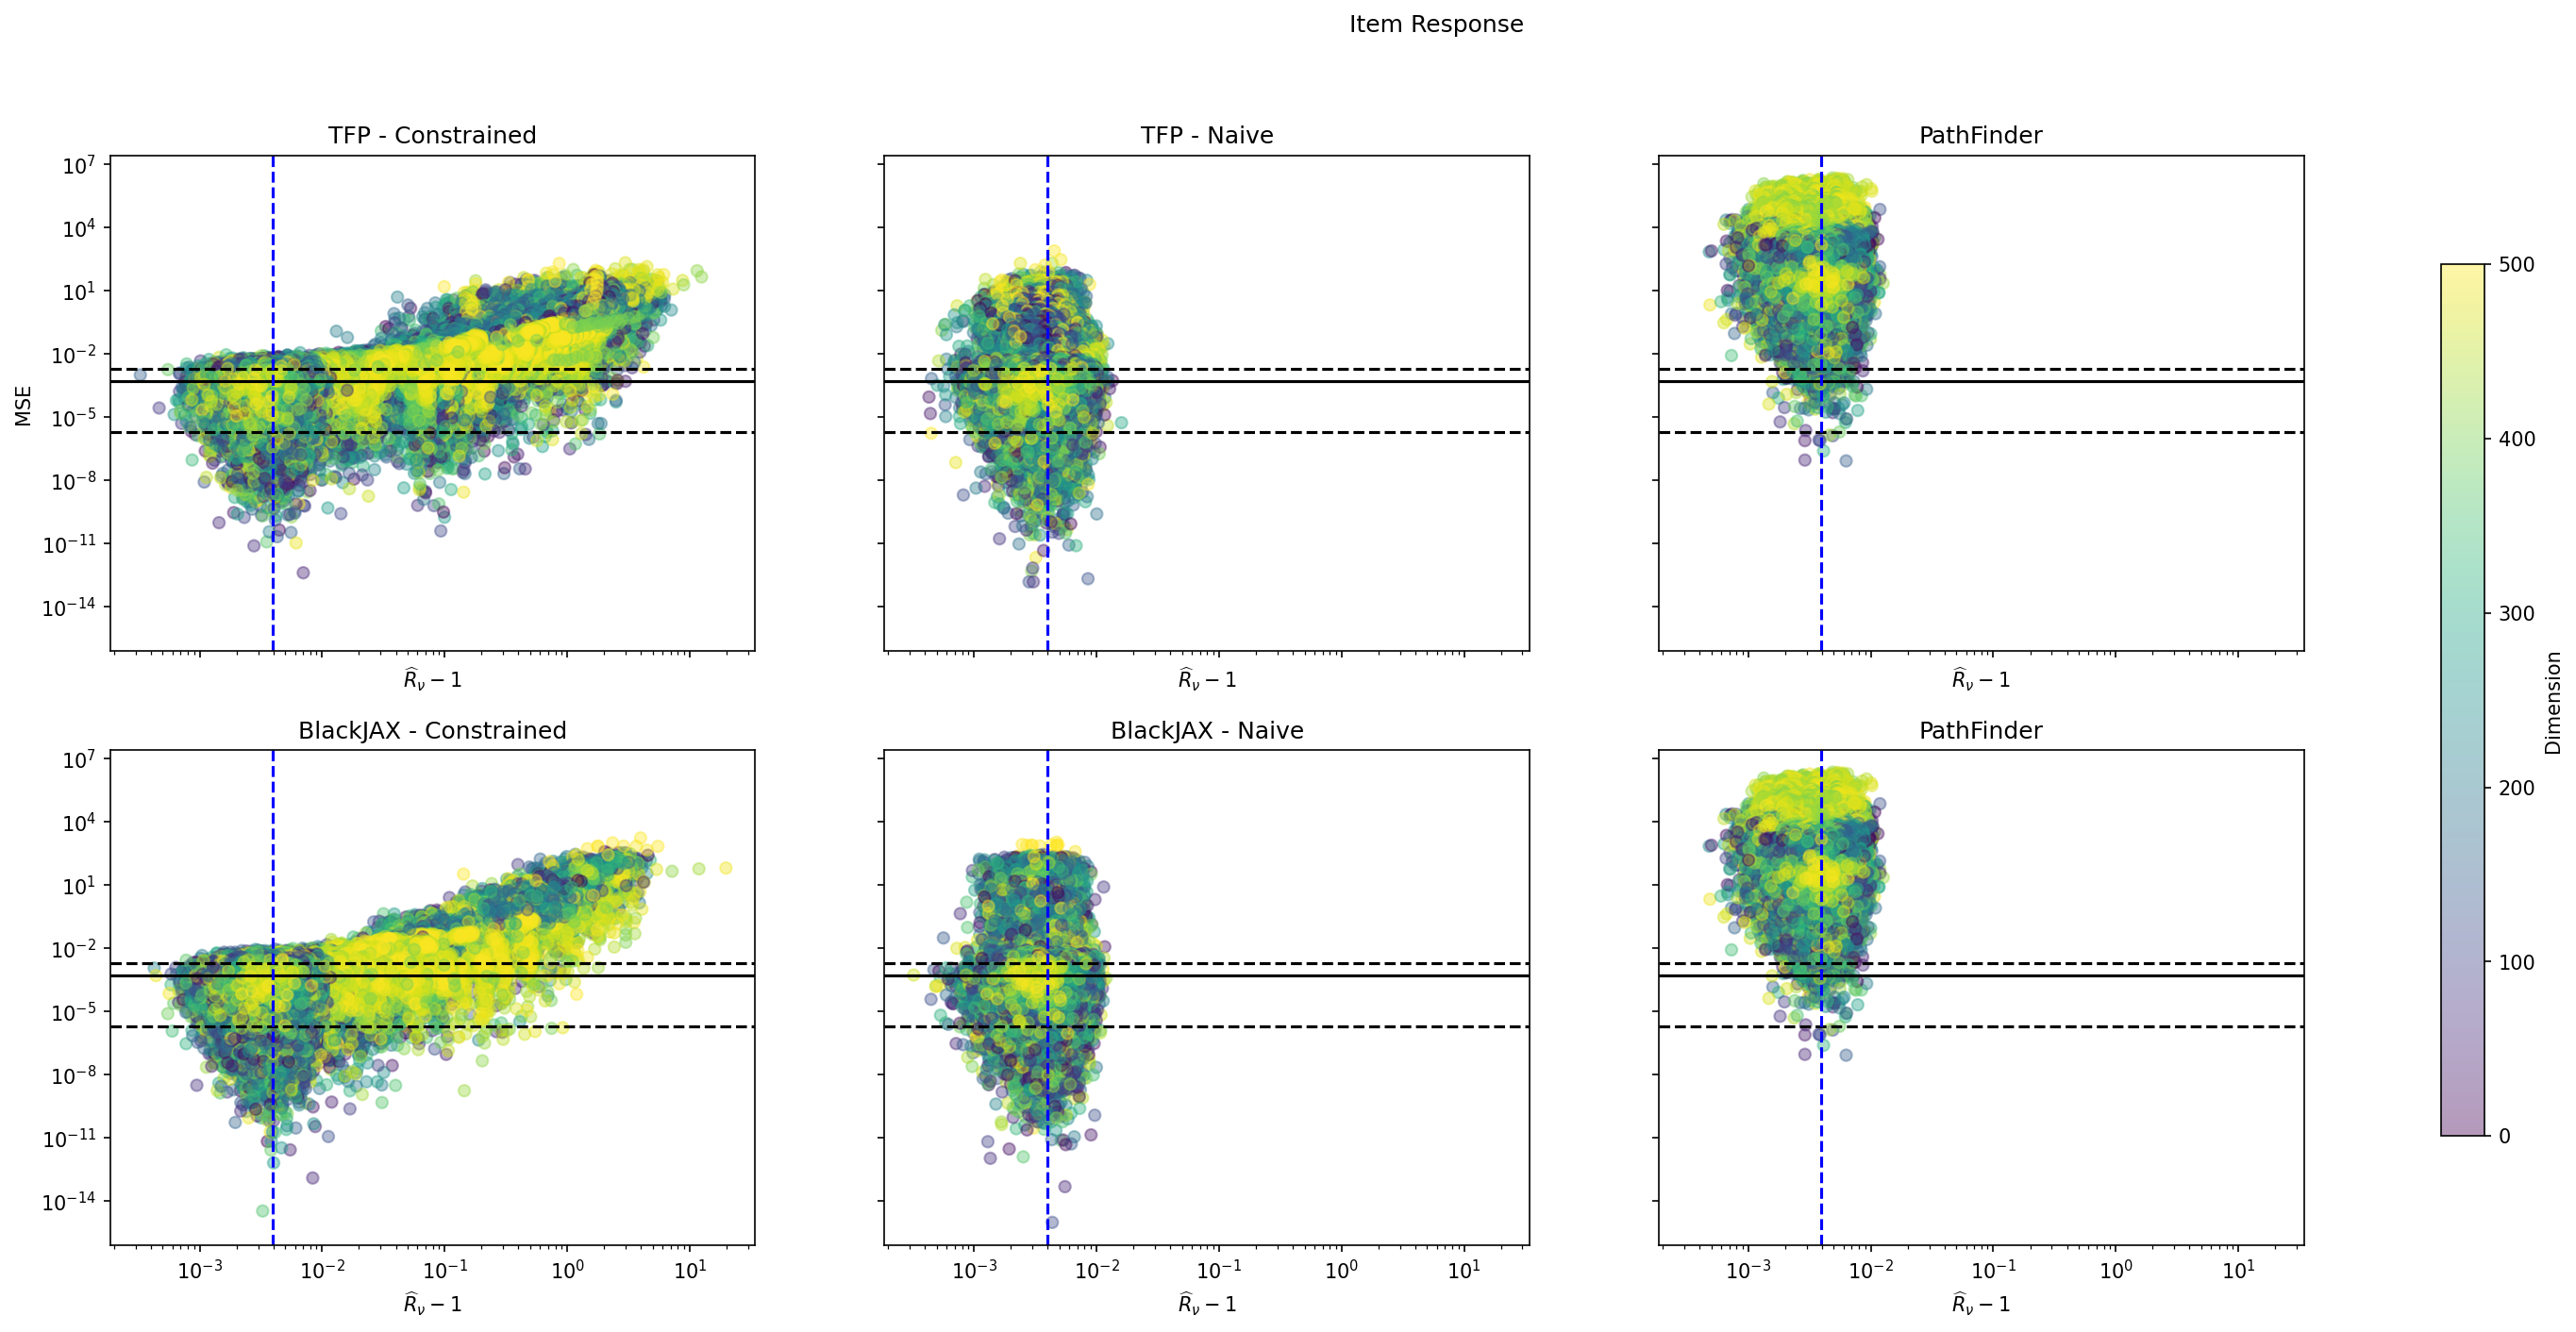

In [66]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Item Response",bound, threshold,num_chains_short,"Dimension")

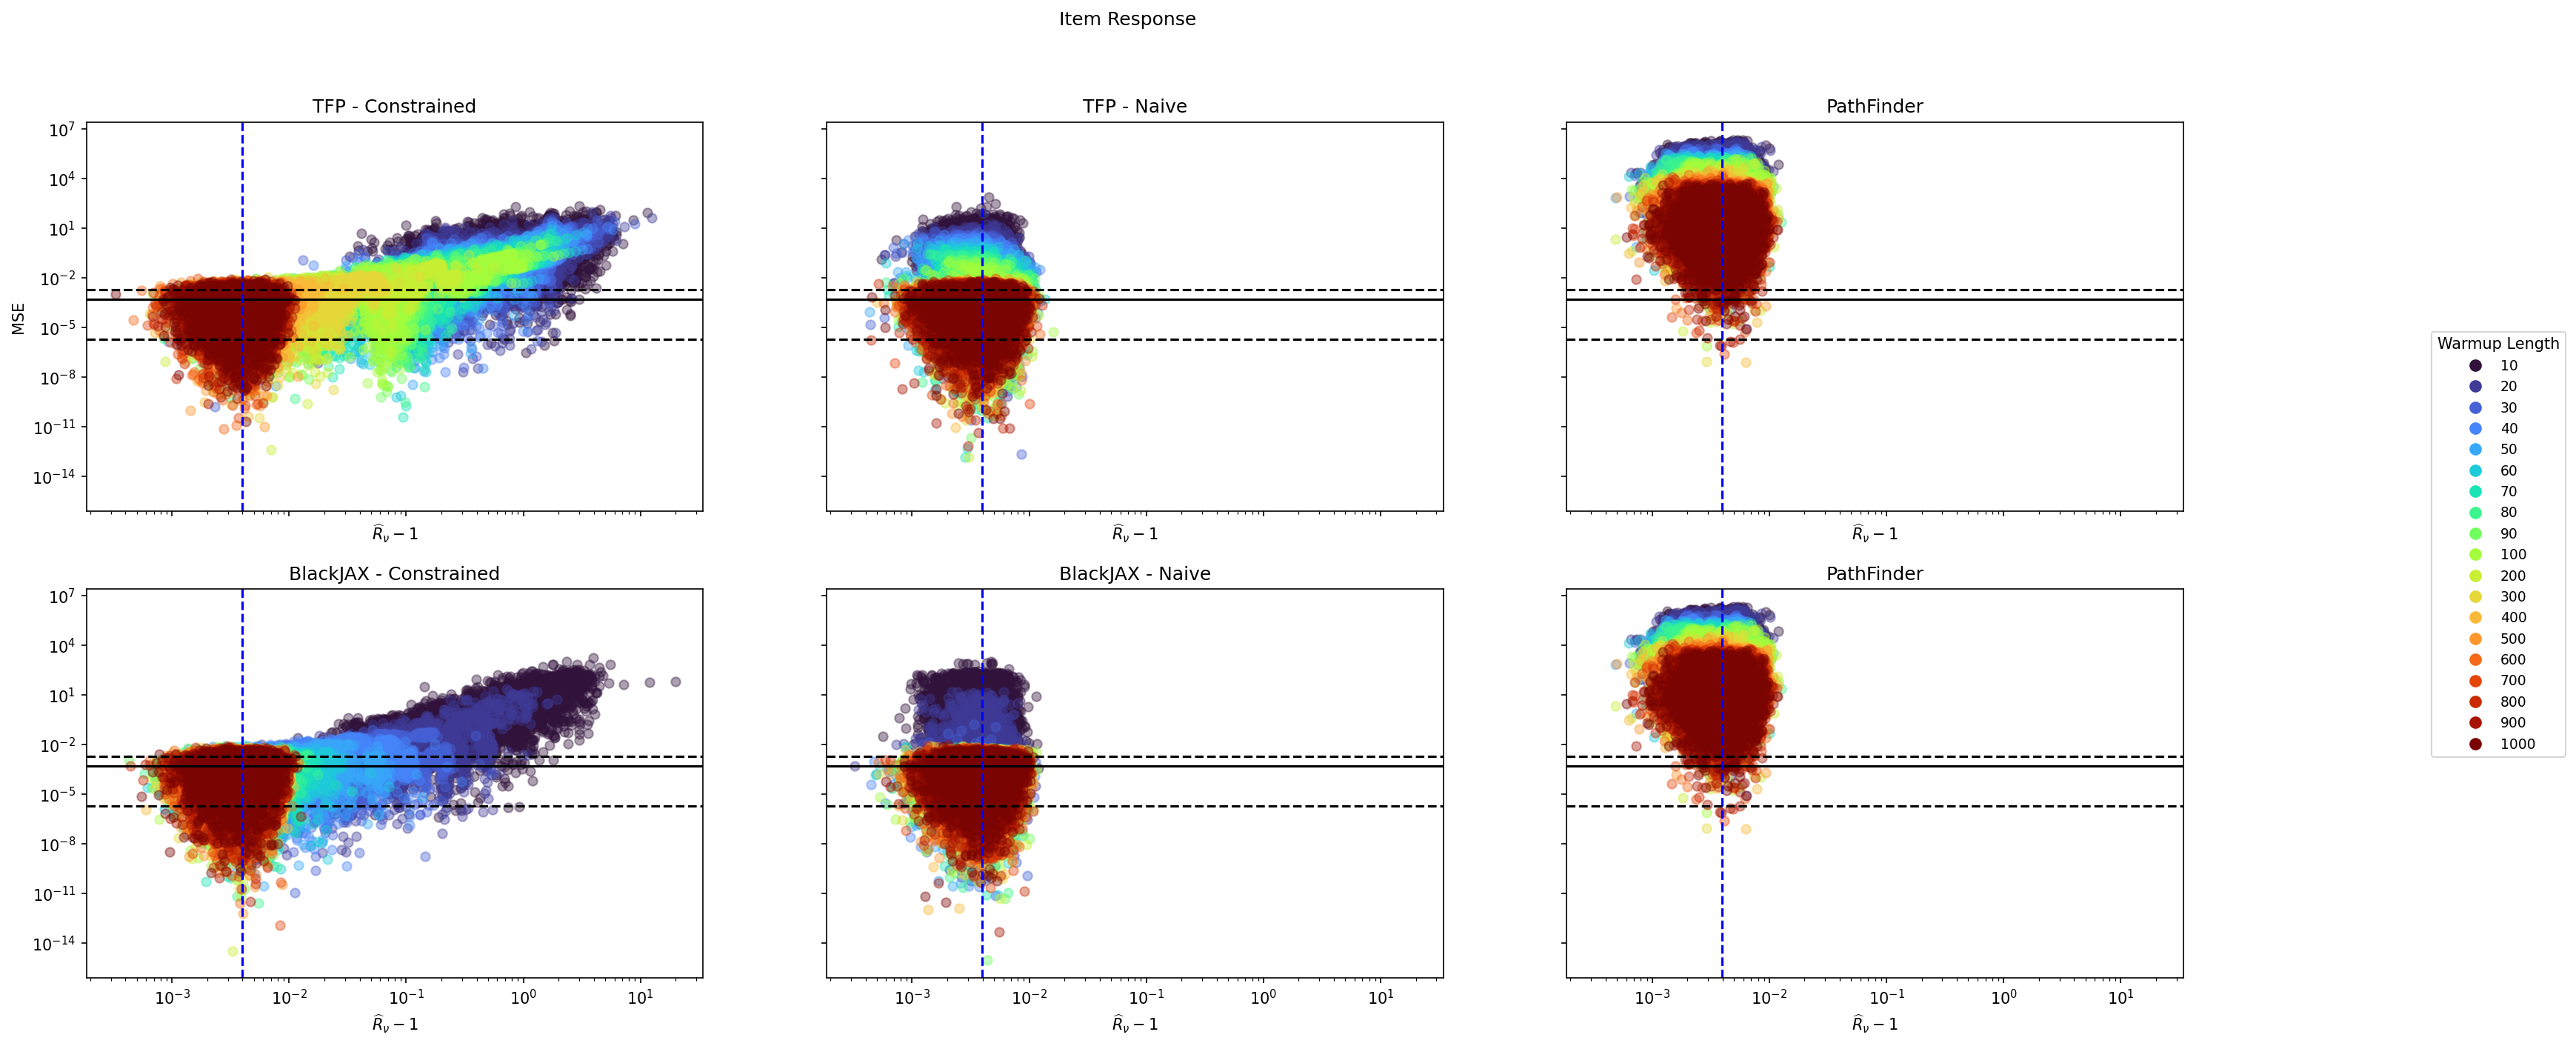

In [67]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Item Response",bound, threshold,num_chains_short,"Warmup Length")